# Personal Information
Name: **Buğra Sipahioğlu**

StudentID: **14318334**

Email: [**bugra.sipahioglu@student.uva.nl**](youremail@student.uva.nl)

Submitted on: **23.03.2026**

# Data Context


This study draws on two complementary datasets from the domains of event extraction and computational narratology. The first is MAVEN (MAssive eVENt detection dataset; Wang et al., 2020), a large-scale, document-level event detection benchmark derived from encyclopedic Wikipedia articles covering real-world events. MAVEN provides a fine-grained ontology of over 160 event types with annotated event triggers and negative triggers across 4,480 documents, and serves as the supervised training resource for the event extraction backbone (BERT+CRF) used in our pipeline. The second is Tell Me Again! (Hatzel & Biemann, 2024), a multilingual narrative similarity corpus containing approximately 29,505 unique narrative works and over 109,000 independently written plot summaries collected from Wikipedia in five languages (English, German, French, Italian, and Spanish). Summaries of the same underlying work form relevance clusters, which enables us to conduct retrieval-based evaluation of narrative similarity.


Together, these datasets support a two-stage research design: MAVEN enables robust, supervised extraction of structured event representations from narrative text, while Tell Me Again! provides the evaluation framework for measuring whether explicitly modeling temporal and causal relations between those events improves the retrieval of narratively similar stories beyond event-only and implicit dense embedding approaches. Both datasets are publicly available, Wikipedia-derived resources, though they differ in domain focus -- MAVEN covers factual, encyclopedic event descriptions whereas Tell Me Again! spans fictional plot retellings that vary widely in length, detail, and abstraction.

# Data Description

The exploratory data analysis is organized into two parts, one for each dataset.

**MAVEN.** 
The corpus contains 4,498 Wikipedia-derived documents split into train (2,913), validation (710), and test (857). Each document is a JSON object with a title, unique ID, tokenized sentence content, a list of annotated events (each with a type drawn from a 168-class ontology and one or more trigger-span mentions), and a list of negative triggers. No missing values are present in any split, and train and validation exhibit closely matched distributions across all document-level statistics: the mean document length is approximately 11 sentences (~286 tokens), with right-skewed tails extending to substantially longer documents. Vocabulary size and hapax counts similarly parallel between splits, confirming that the validation set is a representative sample of the training distribution. At the univariate level, the event-type distribution follows a pronounced long-tail pattern: the top three types (Causation, Process_start, Attack) each account for roughly 3.4--3.6% of all trigger mentions, while the bottom of the ontology contains many rare types. The corpus is heavily class-imbalanced at the trigger-detection level, with approximately 80.6% of annotated tokens being negative triggers (P(negative)=0.806). Thus, a trivial "always predict negative" baseline achieves 80.6% accuracy, and the majority-type baseline yields only 3.6% accuracy for event-type classification. For our pipeline, we rely on the BERT+CRF model reported by Wang et al. (2020), which achieves 67.8 F1 on the MAVEN trigger-classification benchmark, and we do not aim to improve upon MAVEN event detection itself.



**Tell Me Again!** 
The corpus comprises 29,505 unique narrative works with a total of 109,691 raw summaries in five languages (German: 28,947; English: 26,385; French: 21,862; Italian: 19,737; Spanish: 12,760). To create different versions of the same stories, technical translation to English language has been applied, making multiple English versions of summaries that belong to same work. However, some of the translations were almost identical to each other, which makes the retrieval task unefficient. Thus, they removed near-duplicate summaries of the same work (i.e., cosine similarity between them exceeds the threshold of 0.6), making the length of the dataset 97,813 summaries long. Summary lengths differ substantially across languages: English, German, and French summaries are comparably long, while Italian and Spanish tend to be shorter. Deduplication produces 423 singleton clusters (works with only one usable summary), which must be excluded from retrieval evaluation. A series of data-quality inspections revealed: 1,112 stories lack genre metadata (relevant if stratified sampling by genre is needed); 3,120 stories lack a native English summary, but 2,698 of those still have at least 2 English summaries from machine translation and are therefore pipeline-eligible; 1 story has no translated summaries at all and should be excluded; and 32 stories have blank Wikidata descriptions (not critical for our pipeline). After applying pipeline-eligibility criteria (≥2 deduplicated English summaries and at least one translated summary), 29,082 works remain (98.6% of the full corpus), of which 90.7% possess a native English summary and 9.3% rely solely on translations.

A context-window analysis using the Llama-3-8B-Instruct tokenizer shows that per-summary token counts have a right-skewed distribution (mean ≈ 1,509, median = 1,250, std ≈ 1,222). Only 14 summaries (from 14 distinct stories) exceed the 8,192-token context limit; after removing these outlying summaries, 11 of the 14 affected stories still retain ≥2 usable summaries and remain viable for retrieval evaluation. A split-representation analysis using the official train/dev/test partitions confirms that these splits are representative of the full pipeline-eligible corpus with respect to summary length distributions, number of genres, and genre-type proportions. Finally, the SimilarityDataset -- which uses the same official train/dev/test split to construct positive/negative summary pairs for similarity evaluation -- is perfectly class-balanced across all splits: 50% positive (same-story) and 50% negative (different-story) pairs (train: 209,160 pairs; dev: 26,160; test: 26,196), which yields a majority-class baseline accuracy of 50.00% that any similarity model must exceed.



In [1]:
# Imports
import os
import numpy as np
import pandas as pd
from tell_me_again import StoryDataset, SimilarityDataset
import json
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.probability import FreqDist
import nltk
from pprint import pprint
from transformers import AutoTokenizer
from tqdm import tqdm
import zipfile
import seaborn as sns

# Download package(s)
nltk.download("punkt_tab", quiet=True)

/Users/bugrasipahioglu/repo/uva-thesis-computational-narrative-analysis/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


True

## Dataset 1: MAVEN

### Data Loading

In [2]:
# Define the core directories
PROJECT_ROOT = os.path.abspath(os.path.join(os.path.dirname("."), ".."))
MAVEN_DIR_RAW = os.path.join(PROJECT_ROOT, "data", "raw", "MAVEN")

# Load the data
df_train = pd.read_json(os.path.join(MAVEN_DIR_RAW, "train.jsonl"), lines=True)
df_val = pd.read_json(os.path.join(MAVEN_DIR_RAW, "valid.jsonl"), lines=True)
df_test = pd.read_json(os.path.join(MAVEN_DIR_RAW, "test.jsonl"), lines=True)

### Analysis 1: Corpus-level Overview
We inspect corpus size (number of documents and variables per split), variable types, and missing values. We also show one example document so the structure of content, events, and negative_triggers is clear.


*MAVEN is a document-level event-detection dataset: each row is one document with title, id, and content (tokenized sentences); in train/validation each document has annotated events (with type and trigger span) and negative_triggers; the test set provides only content and candidates for trigger (and possibly type) prediction.*

In [3]:
# Analyse the shapes of train, valid, and test splits
print("\033[1;33m\nShapes of the splits:\033[0m")
for name, df in [("Train", df_train), ("Valid", df_val), ("Test", df_test)]:
    print(f"  {name}: {df.shape}")

# Print the variable types and non-null counts for all splits
print("\033[1;33m\nVariable types and non-null counts (train):\033[0m"); print(df_train.info())
print("\033[1;33m\nVariable types and non-null counts (validation):\033[0m"); print(df_val.info())
print("\033[1;33m\nVariable types and non-null counts (test):\033[0m"); print(df_test.info())

# Print the missing values per variable
print("\033[1;33m\nMissing values per variable (train):\033[0m\n" + str(df_train.isna().sum()))
print("\033[1;33m\nMissing values per variable (validation):\033[0m\n" + str(df_val.isna().sum()))
print("\033[1;33m\nMissing values per variable (test):\033[0m\n" + str(df_test.isna().sum()))

# Print one full document entity from the train split for inspection
print("\033[1;33m\nExample document from train split (truncated):\033[0m")
sample_doc = df_train.iloc[0].to_dict()
# Limit the example to 3 key fields (e.g., 'title', 'id', and first 1 sentences of content)
limited_doc = {k: sample_doc[k] for k in ['id', 'title'] if k in sample_doc}
if "content" in sample_doc:
    # Show only first sentence's tokens
    limited_doc["content"] = sample_doc["content"][:1]
if "events" in sample_doc:
    limited_doc["events"] = sample_doc["events"][:1]
if "negative_triggers" in sample_doc:
    limited_doc["negative_triggers"] = sample_doc["negative_triggers"][:1]
print(json.dumps(limited_doc, indent=2, ensure_ascii=False))

# Print the number of event types in the corpus
# Count unique event types in the corpus (across train, valid, and test splits, where available)
def get_event_types(df):
    event_types = set()
    if "events" in df.columns:
        for events in df["events"]:
            if isinstance(events, list):
                for event in events:
                    etype = event.get("type")
                    if isinstance(etype, str):
                        event_types.add(etype)
    return event_types

event_types_train = get_event_types(df_train)
event_types_val = get_event_types(df_val)
event_types_test = get_event_types(df_test)

all_event_types = event_types_train.union(event_types_val).union(event_types_test)
print(f"\033[1;33m\nNumber of unique event types in the corpus (across all splits):\033[0m {len(all_event_types)}")




Shapes of the splits:
  Train: (2913, 5)
  Valid: (710, 5)
  Test: (857, 4)

Variable types and non-null counts (train):
<class 'pandas.DataFrame'>
RangeIndex: 2913 entries, 0 to 2912
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   title              2913 non-null   str   
 1   id                 2913 non-null   str   
 2   content            2913 non-null   object
 3   events             2913 non-null   object
 4   negative_triggers  2913 non-null   object
dtypes: object(3), str(2)
memory usage: 113.9+ KB
None

Variable types and non-null counts (validation):
<class 'pandas.DataFrame'>
RangeIndex: 710 entries, 0 to 709
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   title              710 non-null    str   
 1   id                 710 non-null    str   
 2   content            710 non-null    object
 3   events          

### Analysis 2: Pre-variable-level Overview

We describe the corpus before defining model-ready variables: document-level lengths (sentences, tokens), token-count statistics (vocabulary size, hapax count), and annotation counts (events and negative triggers per document). This characterises the raw text and annotations that will later be turned into features.


*We characterised the MAVEN corpus at a pre-variable level by computing, for each document in the train and validation splits, the number of sentences, total tokens, in-document vocabulary size, number of hapax legomena, number of events, and number of negative triggers. Summary statistics and side-by-side comparison showed that train and validation have similar distributions for these quantities, with no missing values in the analysed fields. Document length (sentences and tokens) and annotation counts (events and negative triggers) are right-skewed, with a majority of short to medium documents and a long tail of longer, more event-dense documents. These statistics describe the raw corpus before defining model-ready variables and support the choice of MAVEN for supervised event detection and the assumption that train and validation are comparable for evaluation.*




Combined per-document stats (first 15 rows):


,doc_id,n_sentences,n_tokens,vocab_size,n_hapax,n_events,n_negative_triggers,split
0,8307a6b61b84d4eea42c1dd5e6e2cdba,9,352,175,125,39,117,train
1,387fe1dfe55067eb29e1fd4116d37af3,18,463,234,153,48,159,train
2,268c4763208c87ed7ebf55565c274d23,11,303,166,128,23,138,train
3,c95e68565081126b5c949117e423695a,10,309,162,114,33,114,train
4,3bec0b60c0940c5e46ee2cfc9504df92,10,213,133,96,23,85,train
5,39c2db9e18cd4a02b9aa8c1a3c58aab7,13,267,145,107,33,89,train
6,c1ae08941a115c7d45e205724e5aa3be,39,1215,472,334,75,468,train
7,ef451445d348d837669fbab71d1db3a2,12,295,180,142,32,118,train
8,045be42474c6c6225401d4b8cc03fe5e,8,195,105,75,23,76,train
9,eeb1b3357c409a5f55f45158ce2a62e5,7,118,84,68,15,40,train



Summary (train vs valid):


,train_mean,train_std,valid_mean,valid_std
n_sentences,11.133196,5.468577,11.326761,6.460926
n_tokens,285.680055,152.267703,288.107042,172.912803
vocab_size,152.967044,64.632639,153.097183,69.264933
n_hapax,112.732578,47.421373,112.452113,49.685639
n_events,25.230347,16.089320,24.966197,16.614232
n_negative_triggers,111.222794,61.776284,112.252113,69.998709



Describe by split:


n_sentences                                                  n_tokens  \
            count       mean       std  min  25%   50%   75%   max    count   
split                                                                         
train      2913.0  11.133196  5.468577  6.0  7.0  10.0  13.0  57.0   2913.0   
valid       710.0  11.326761  6.460926  6.0  7.0   9.0  14.0  75.0    710.0   

                   ... n_events        n_negative_triggers              \
             mean  ...      75%    max               count        mean   
split              ...                                                   
train  285.680055  ...     32.0  122.0              2913.0  111.222794   
valid  288.107042  ...     32.0  128.0               710.0  112.252113   

                                                   
             std   min   25%   50%     75%    max  
split                                              
train  61.776284  22.0  69.0  96.0  137.00  845.0  
valid  69.998709  23.0  69.0  93.5  136.75  777.0  

[2 rows x 48 columns]

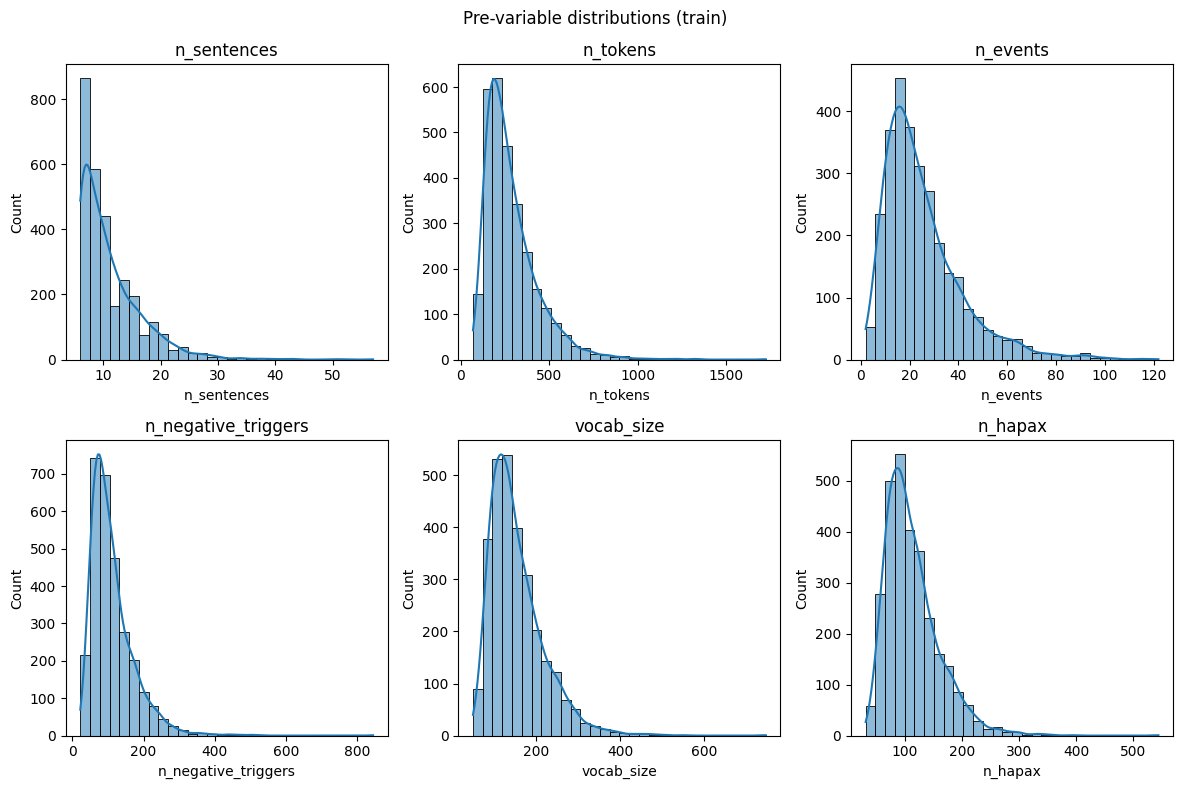

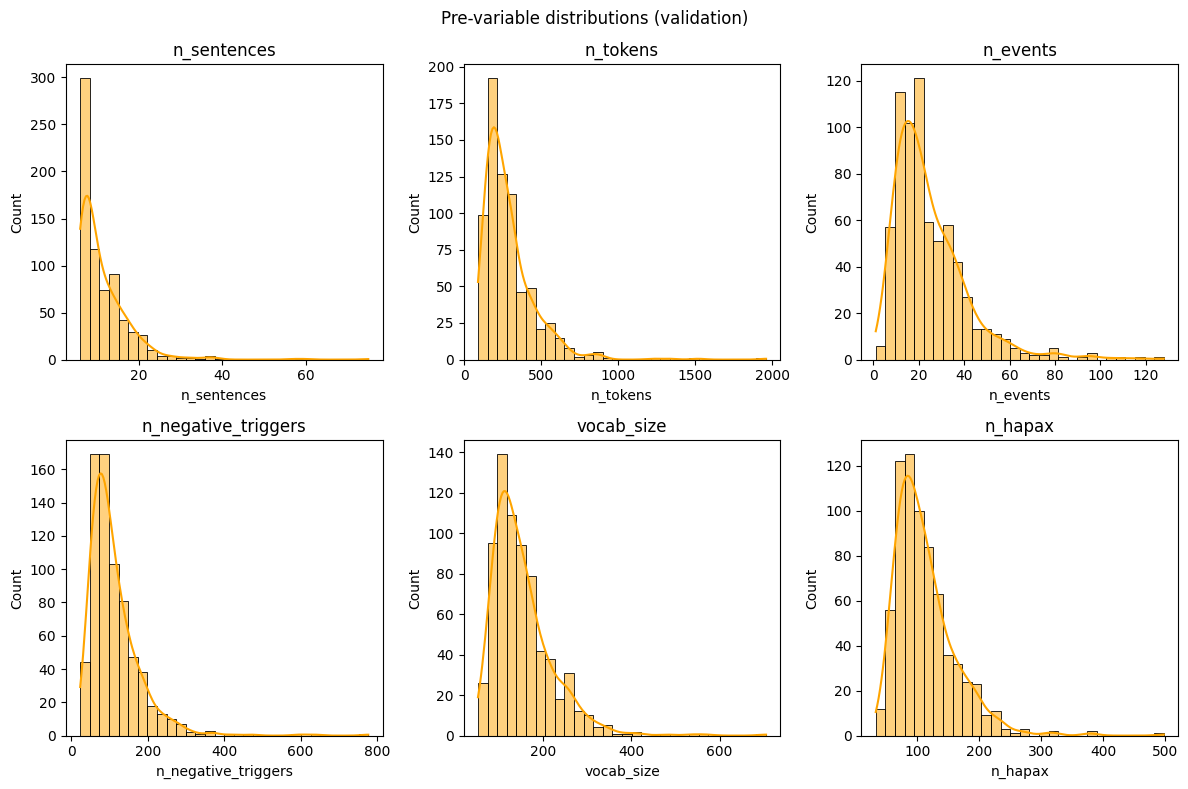

In [4]:
def prevariable_stats(df):
    """
    Computes per-document statistics from a MAVEN event detection dataset dataframe.

    Parameters
    ----------
    df : pd.DataFrame
        Dataframe in MAVEN format: each row is a document with at least a `content` 
        (list of sentence dicts with "tokens"), and optionally columns 'events' and 
        'negative_triggers'.

    Returns
    -------
    pd.DataFrame
        Dataframe with one row per document containing the following columns:
            - n_sentences: Number of sentences in document
            - n_tokens: Number of tokens in document
            - vocab_size: Number of unique tokens (vocabulary size) in document
            - n_hapax: Number of tokens that occur only once (hapax legomena) in document
            - n_events: Number of events in document (if present)
            - n_negative_triggers: Number of negative triggers in document (if present)
    """
    # get the num of sentences, tokens, events, and negative triggers
    n_sentences = df["content"].map(len)
    n_tokens = df["content"].map(lambda c: sum(len(s["tokens"]) for s in c))
    n_events = df["events"].map(len) if "events" in df.columns else None
    n_neg = df["negative_triggers"].map(len) if "negative_triggers" in df.columns else None

    # For each document, extract tokens and compute vocabulary size and hapax count.
    def vocab_and_hapax(content_list):
        tokens = [t for sent in content_list for t in sent["tokens"]]
        fdist = FreqDist(tokens)
        return len(fdist), len(fdist.hapaxes())

    # Apply the function to each document in the dataframe
    vocab_size, n_hapax = zip(*df["content"].map(vocab_and_hapax))

    # Create a dataframe with the computed statistics
    out = pd.DataFrame({"n_sentences": n_sentences, "n_tokens": n_tokens, "vocab_size": vocab_size, "n_hapax": n_hapax})
    if n_events is not None:
        out["n_events"] = n_events
    if n_neg is not None:
        out["n_negative_triggers"] = n_neg
    return out

# Compute per-document stats
stats_train = prevariable_stats(df_train)
stats_val = prevariable_stats(df_val)

# One combined dataframe with split and doc_id
stats_train_labeled = stats_train.assign(split="train")
stats_val_labeled = stats_val.assign(split="valid")
stats_all = pd.concat([stats_train_labeled, stats_val_labeled], ignore_index=True)
stats_all.insert(0, "doc_id", np.concatenate([df_train["id"].values, df_val["id"].values]))

# Summary dataframe: train vs valid side by side (mean, std)
summary_side_by_side = pd.DataFrame({
    "train_mean": stats_train.mean(),
    "train_std": stats_train.std(),
    "valid_mean": stats_val.mean(),
    "valid_std": stats_val.std(),
})

# Print all the stats
print("\033[1;33m\nCombined per-document stats (first 15 rows):\033[0m"); display(stats_all.head(15))
print("\033[1;33m\nSummary (train vs valid):\033[0m"); display(summary_side_by_side)
print("\033[1;33m\nDescribe by split:\033[0m"); display(stats_all.groupby("split").describe())


# Define the columns to plot histograms
cols = ["n_sentences", "n_tokens", "n_events", "n_negative_triggers", "vocab_size", "n_hapax"]

# Plot for train
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, col in zip(axes.flat, cols):
    if col in stats_train.columns:
        sns.histplot(stats_train[col], kde=True, ax=ax, bins=30)
        ax.set_title(col)
    else:
        ax.axis('off')
plt.suptitle("Pre-variable distributions (train)", fontsize=12)
plt.tight_layout()
plt.show()

# Plot for validation
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, col in zip(axes.flat, cols):
    if col in stats_val.columns:
        sns.histplot(stats_val[col], kde=True, ax=ax, bins=30, color='orange')
        ax.set_title(col)
    else:
        ax.axis('off')
plt.suptitle("Pre-variable distributions (validation)", fontsize=12)
plt.tight_layout()
plt.show()

### Analysis 3: Univariate-level Overview

We look at one variable at a time: event type (and type_id) distribution across the corpus, trigger-word frequency, and the class balance between event triggers and negative triggers. This yields priors for event-type classification and for binary trigger detection, and shows the long-tail nature of the event ontology.


TRAIN
Event type (categorical) — value counts (top 20):
Causation             2653
Process_start         2562
Attack                2535
Hostile_encounter     2411
Catastrophe           2172
Motion                2109
Competition           2032
Killing               1487
Process_end           1374
Social_event          1369
Conquering            1353
Statement             1350
Self_motion           1241
Arriving              1217
Destroying            1136
Coming_to_be          1093
Bodily_harm           1007
Death                  963
Creating               924
Military_operation     920
Name: count, dtype: int64

Event type_id (numeric) — describe:
count    73496.000000
mean        51.593787
std         40.285666
min          1.000000
25%         19.000000
50%         40.000000
75%         82.000000
max        168.000000
dtype: float64

Prior P(type) — top 20:
Causation             0.036097
Process_start         0.034859
Attack                0.034492
Hostile_encounter     0.032805


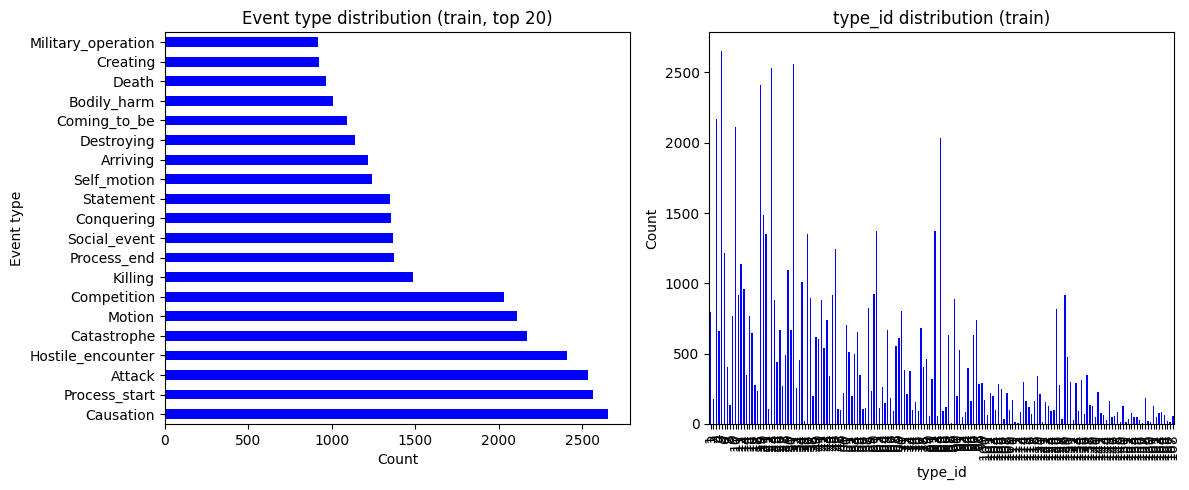


VALID
Event type (categorical) — value counts (top 20):
Hostile_encounter                      646
Causation                              644
Process_start                          629
Competition                            593
Catastrophe                            577
Attack                                 524
Motion                                 424
Killing                                352
Process_end                            331
Statement                              327
Self_motion                            324
Social_event                           320
Conquering                             308
Arriving                               304
Coming_to_be                           294
Destroying                             261
Damaging                               239
Cause_change_of_position_on_a_scale    233
Becoming                               233
Bodily_harm                            228
Name: count, dtype: int64

Event type_id (numeric) — describe:
count    17726.00000

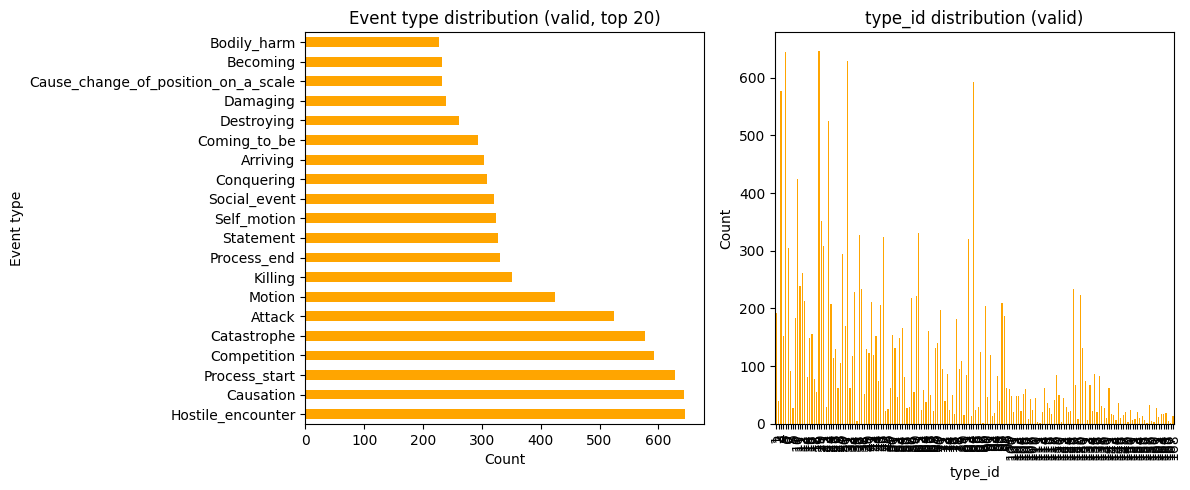

In [5]:
def get_event_type_series(df):
    """Collect (type, type_id) for every event in df. Returns (type_series, type_id_series)."""
    all_types = []
    all_type_ids = []
    for _, row in df.iterrows():
        for ev in row["events"]:
            all_types.append(ev["type"])
            all_type_ids.append(ev["type_id"])
    return pd.Series(all_types), pd.Series(all_type_ids)

def get_trigger_balance(df):
    """Return (n_positive, n_negative, total) trigger spans."""
    n_positive = sum(len(ev.get("mention", [])) for _, row in df.iterrows() for ev in row["events"])
    n_negative = df["negative_triggers"].map(len).sum()
    total = n_positive + n_negative
    return n_positive, n_negative, total

def get_trigger_word_counts(df):
    """Return Series of trigger-word value counts."""
    words = []
    for _, row in df.iterrows():
        for ev in row["events"]:
            for m in ev.get("mention", []):
                w = m.get("trigger_word")
                if w is not None:
                    words.append(w)
    return pd.Series(words).value_counts()

def run_univariate_for_split(df, split_name, n_top=20, plot=True):
    """Run full univariate analysis for one split (train or valid)."""
    type_series, type_id_series = get_event_type_series(df)
    n_events = len(type_series)

    print(f"\033[1;33m\n{split_name.upper()}\033[0m")
    print(f"\033[1mEvent type (categorical) — value counts (top {n_top}):\033[0m")
    print(type_series.value_counts().head(n_top))
    print("\033[1m\nEvent type_id (numeric) — describe:\033[0m")
    print(type_id_series.describe())
    prior_top = type_series.value_counts().head(n_top) / n_events
    print(f"\033[1m\nPrior P(type) — top {n_top}:\033[0m")
    print(prior_top)

    n_pos, n_neg, total = get_trigger_balance(df)
    print(f"\033[1m\nTrigger vs negative:\033[0m \n - positive: {n_pos}, \n - negative: {n_neg}, \n - total: {total}")
    print(f"\033[1mPriors: \033[0m \n - P(positive) = {n_pos / total:.4f}, \n - P(negative) = {n_neg / total:.4f}")
    print("\033[1m\nTop 20 trigger words:\033[0m")
    print(get_trigger_word_counts(df).head(20))

    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        # Set color: train = blue, val = orange
        color = "blue" if split_name.lower() == "train" else "orange"
        type_series.value_counts().head(n_top).plot(kind="barh", ax=axes[0], color=color)
        axes[0].set_xlabel("Count")
        axes[0].set_ylabel("Event type")
        axes[0].set_title(f"Event type distribution ({split_name}, top {n_top})")
        type_id_series.value_counts().sort_index().plot(kind="bar", ax=axes[1], color=color)
        axes[1].set_xlabel("type_id")
        axes[1].set_ylabel("Count")
        axes[1].set_title(f"type_id distribution ({split_name})")
        plt.tight_layout()
        plt.show()

# Run for both splits
for name, data in [("train", df_train), ("valid", df_val)]:
    run_univariate_for_split(data, name, n_top=20, plot=True)

### Analysis 4: Baseline

We derive trivial baseline scores from the corpus priors (trigger vs negative and event-type distribution) so we have a lower bound any real model must beat. We then briefly reference the MAVEN benchmark (Wang et al., 2020): BERT+CRF reaches 67.8 F1 on MAVEN trigger classification; we use this model as our event extractor for the Tell Me Again pipeline and do not aim to improve MAVEN event detection itself.

*We use the MAVEN dataset for supervised event detection. From the training set, we computed trivial baselines: always predicting the negative class yields accuracy equal to the proportion of negative triggers (P(negative)), while always predicting the majority event type yields accuracy equal to the prior of the most frequent type. Any meaningful event detector must exceed these prior baselines. As the extractor, we rely on the BERT+CRF model reported by Wang et al. (2020), which achieves 67.8 F1 on MAVEN trigger classification. We do not aim to improve event detection on MAVEN but instead use it as an off-the-shelf component for our narrative similarity pipeline on the Tell Me Again dataset.*



In [6]:
# Calculate priors for trigger vs negative trigger detection
n_pos, n_neg, total = get_trigger_balance(df_train)
p_neg = n_neg / total
p_pos = n_pos / total

# Calculate priors for event type classification
type_series, _ = get_event_type_series(df_train)
n_events = len(type_series)
majority_type = type_series.value_counts().index[0]
majority_count = type_series.value_counts().iloc[0]
p_majority_type = majority_count / n_events

print(f"\033[1;33m\nPrior baselines (train)\033[0m")
print(f"\033[1m  • Trigger vs negative:\033[0m \n - P(negative) = {p_neg:.4f} → 'always predict negative' accuracy = {p_neg:.4f}")
print(f"\033[1m  • Event type:\033[0m \n - majority type = '{majority_type}' (P = {p_majority_type:.4f}) → 'always predict majority' accuracy = {p_majority_type:.4f}")

# Print a summary table of the baseline accuracies
print("\033[1;33m\nBaseline accuracies from corpus priors (train set)\033[0m")
baseline_summary = pd.DataFrame({
    "Baseline": [
        "Always negative (trigger detection)",
        "Majority event type (type classification)",
    ],
    "Train accuracy": [p_neg, p_majority_type],
})
display(baseline_summary)

# 2) MAVEN paper benchmark (for methodology / related work)
print("\nMAVEN benchmark (Wang et al., 2020, Table 5 — trigger classification on MAVEN test):")
print("  • BERT+CRF: P=65.0, R=70.9, F1=67.8 (best in paper)")
print("  • We use BERT+CRF as the event extractor; our thesis focus is on Tell Me Again, not improving MAVEN ED.")


Prior baselines (train)
  • Trigger vs negative: 
 - P(negative) = 0.8060 → 'always predict negative' accuracy = 0.8060
  • Event type: 
 - majority type = 'Causation' (P = 0.0361) → 'always predict majority' accuracy = 0.0361

Baseline accuracies from corpus priors (train set)


,Baseline,Train accuracy
0,Always negative (trigger detection),0.805980
1,Majority event type (type classification),0.036097



MAVEN benchmark (Wang et al., 2020, Table 5 — trigger classification on MAVEN test):
  • BERT+CRF: P=65.0, R=70.9, F1=67.8 (best in paper)
  • We use BERT+CRF as the event extractor; our thesis focus is on Tell Me Again, not improving MAVEN ED.


## Dataset 2: TellMeAgain!

### Data Loading

In [7]:
# Define the core directories
PROJECT_ROOT = os.path.abspath(os.path.join(os.path.dirname("."), ".."))
TELL_ME_AGAIN_ZIP_RAW = os.path.join(PROJECT_ROOT, "data", "raw", "TellMeAgain", "tell_me_again_v1.zip")

# Load the story-level corpus via zip file
storyDataset = StoryDataset(data_path=TELL_ME_AGAIN_ZIP_RAW)
similarityDataset = SimilarityDataset(data_path=TELL_ME_AGAIN_ZIP_RAW)   # There is a recorded bug, so download for now (by leaving the data_path empty). TODO: change API code?

Loading summaries: 100%|██████████| 29505/29505 [00:16<00:00, 1834.23it/s]


### Analysis 1: Corpus-level Overview

**In the cell below:**
- We iterate over each story in the TellMeAgain dataset.
- For each story, we collect various statistics, including the number of summaries in original and deduplicated form, presence of English or anonymized summaries, sentence count statistics, number of genres, and available languages.
- Each row in the resulting DataFrame represents a single story, containing all the collected statistics (e.g., Wikidata ID, number of summaries, languages, sentence counts, genres) for that story, allowing for easy analysis and display of the entire corpus.

**Observations:**
- Number of sentences with respect to languages differ: Although EN, DE, and FR have similar lengths/stds, IT and ES have significantly lower length.
- Singletons: Stories for which only one summary was collected in the original language, so there is only a single summary in the cluster.
- Deduplication: If the translated summaries of the same work has > 0.6 cosine similarity, the one with lower language-priority is filtered out at API runtime (`get_all_summaries_en()`)
- English summaries are not deduplicated as they are always the original summaries, not translations, so the 'n_deduped' will be 0 for them. 
- 423 stories did have multiple summaries, however the deduplication process removed all of these summaries, making them singletons. 



Dataframe shape:
  29,505 rows × 13 columns

Corpus dimensions:
  - Total stories (unique works):                                            29,505
  - Total summaries – raw (all languages):                                  109,691
  - Total summaries – after deduplication:                                   97,813
  - Stories with translated summaries:                                       29,504  (100.0%)
  - Stories with an English summary:                                         26,385  (89.4%)
  - Stories with anonymized summaries:                                       29,505  (100.0%)
  - Singleton clusters (n_deduped == 1):                                        423  (1.4%) --> should be excluded from retrieval eval
  - Singleton clusters (number of summaries before deduplication == 1):          0  (0.0%)  --> should be excluded from retrieval eval


100%|██████████| 29505/29505 [00:00<00:00, 97525.58it/s]


Number of summaries per language:
(Note: English summaries are not deduplicated as they are always the original summaries, not translations, so the 'n_deduped' will be 0)


,language,n_raw,n_deduped
0,de,28947,25408
1,en,26385,0
2,fr,21862,21848
3,it,19737,15548
4,es,12760,8624



Number of sentences per language version:


,count,mean,std,min,25%,50%,75%,max
lang,,,,,,,,
de,28942.0,22.877721,20.513467,1.0,10.0,18.0,30.0,517.0
en,26385.0,22.517567,16.947168,0.0,8.0,22.0,33.0,261.0
es,12754.0,15.606241,21.156852,1.0,4.0,7.0,24.0,1188.0
fr,21848.0,11.004760,16.807870,1.0,3.0,5.0,11.0,418.0
it,19733.0,13.733746,14.424066,1.0,4.0,9.0,20.0,270.0



Missing values:
  - Stories with no anonymized summaries: 0
  - Stories with no genres: 1112
  - Stories with no English original (but can have multiple EN summaries): 3120
  - Stories with no similarities matrix: 0
  - Stories with empty summaries_original:   0
  - Stories with empty summaries_translated: 1
  - Stories with empty titles dict:          0
  - Stories with empty num_sentences:       0
  - Stories with empty sentences:            0
  - Stories with empty similarities_labels: 0
  - Stories with blank description:        32
  - Stories with blank title:               0


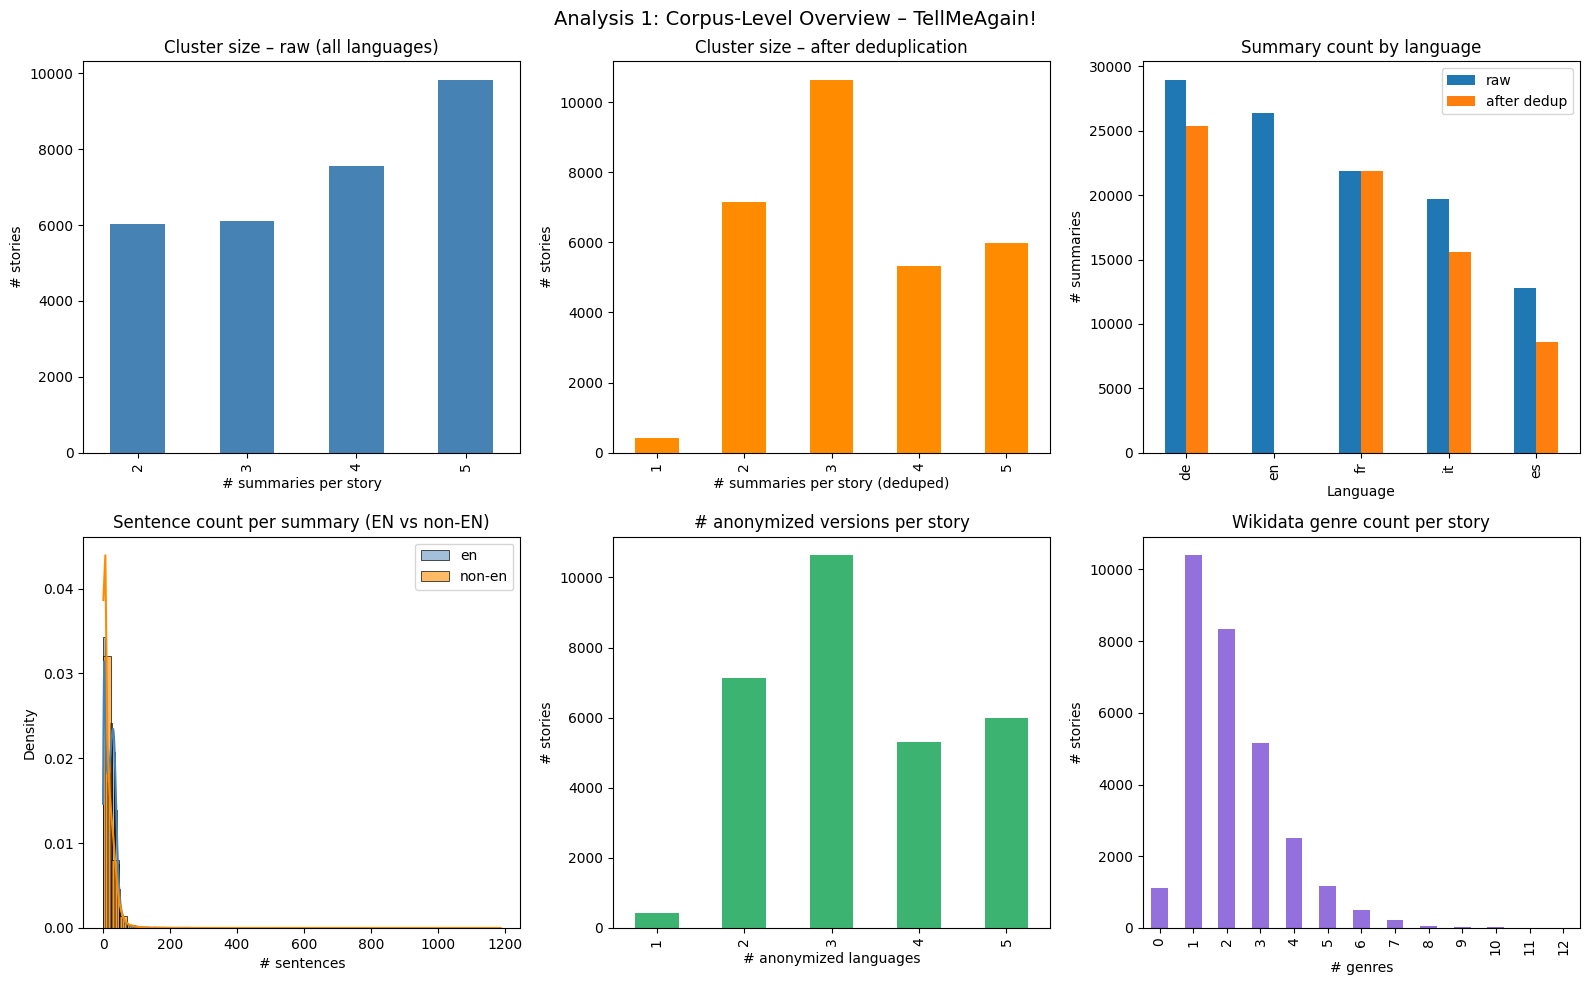


Example Story: 
<Story title='Reckless' description='2010 young adult novel by Cornelia Funke'>
  wikidata_id:   Q1000352
  title:         Reckless
  description:   2010 young adult novel by Cornelia Funke
  Languages present: ['en', 'de', 'it']
  num_sentences:     {'de': 28, 'it': 6, 'en': 63}
  genres (Q-IDs):    ['Q132311', 'Q111984153']
  anonymized langs:  ['en', 'de', 'it']
  get_all_summaries_en → 3 summaries after dedup

  EN summary (first 400 chars):
  Reckless opens with twelve-year-old Jacob Reckless using a mirror to enter the magical world of Mirrorworld.
Twelve years later, Jacob's brother Will follows Jacob into the Mirrorworld. Will is attacked by a Goyl, a humanoid race with stone skin. As a result of this, Will's skin begins turning to stone. Jacob knows that the stone will soon invade Will's entire body, and Will will become one of the...

Example summaries:

  Summary 1:
    Reckless opens with twelve-year-old Jacob Reckless using a mirror to enter the magical wo

In [8]:
# Build a statistics dataframe for the corpus where each row is a story and columns represent the corpus-level statistics
records = []
for story in storyDataset:

    # Raw cluster size (all original languages)
    numSummariesRaw = len(story.summaries_original)
    languagesRaw = list(story.summaries_original.keys())

    # Get the number of deduplicated summaries (i.e., summaries that become near-duplicates after translation are removed)
    ids_deduped, summaries_deduped = story.get_all_summaries_en()
    numSummariesDeduped = len(summaries_deduped)

    # Get the number of anonymized summaries
    numSummariesAnonymized = len(story.summaries_anonymized) if story.summaries_anonymized else 0

    # Get the sentence count statistics across all language versions of this story
    numSentences = list(story.num_sentences.values())
    avgSentences = sum(numSentences) / len(numSentences) if numSentences else 0
    maxSentences = max(numSentences) if numSentences else 0
    minSentences = min(numSentences) if numSentences else 0
    stdSentences = np.std(numSentences) if numSentences else 0

    # Append all of the statistics to the records
    records.append({
        "wikidata_id":         story.wikidata_id,                       # What is the wikidata id of the story?
        "n_summaries_raw":     numSummariesRaw,                         # How many summaries are there in the original language?
        "n_summaries_deduped": numSummariesDeduped,                     # How many summaries are there in the deduplicated language?
        "has_en":              "en" in story.summaries_original,        # Is English one of the original languages?
        "n_anon_langs":        numSummariesAnonymized,                  # How many anonymized summaries are there?
        "has_anonymized":      numSummariesAnonymized > 0,              # Are there any anonymized summaries?
        "has_translated_summaries": bool(story.summaries_translated),   # Does the story have any translated summaries?
        "avg_sentences":       avgSentences,                            # What is the average number of sentences in the summaries?
        "max_sentences":       maxSentences,                            # What is the maximum number of sentences in the summaries?
        "min_sentences":       minSentences,                            # What is the minimum number of sentences in the summaries?
        "std_sentences":       stdSentences,                            # What is the standard deviation of the number of sentences in the summaries?
        "n_genres":            len(story.genres),                       # How many genres are there in the story?
        "langs":               languagesRaw,                            # What are the languages of the summaries?
    })

# Create a dataframe from the records dictionary
story_df = pd.DataFrame(records)

# Print the dataframe
story_df.head()

# Print the dataframe shape
print("\033[1;33m\nDataframe shape:\033[0m")
print(f"  {story_df.shape[0]:,} rows × {story_df.shape[1]} columns")

# Get the corpus dimensions
total_stories    = len(story_df)                                                # Number of unique works in the corpus.
total_raw        = story_df["n_summaries_raw"].sum()                            # Number of summaries in the raw corpus.
total_deduped    = story_df["n_summaries_deduped"].sum()                        # Number of summaries after deduplication.
singleton_count_before_dedup = (story_df["n_summaries_raw"] == 1).sum()         # unretrievable stories: Before deduplication, stories already have only one summary.
singleton_count_after_dedup  = (story_df["n_summaries_deduped"] == 1).sum()     # unretrievable stories: After deduplication, stories have only one summary left.

# Print the corpus dimensions
print("\033[1;33m\nCorpus dimensions:\033[0m")
print(f"  - Total stories (unique works):          {total_stories:>40,}")
print(f"  - Total summaries – raw (all languages): {total_raw:>40,}")
print(f"  - Total summaries – after deduplication: {total_deduped:>40,}")
print(f"  - Stories with translated summaries:     {story_df['has_translated_summaries'].sum():>40,}  ({story_df['has_translated_summaries'].mean()*100:.1f}%)")
print(f"  - Stories with an English summary:       {story_df['has_en'].sum():>40,}  ({story_df['has_en'].mean()*100:.1f}%)")
print(f"  - Stories with anonymized summaries:     {story_df['has_anonymized'].sum():>40,}  ({story_df['has_anonymized'].mean()*100:.1f}%)")
print(f"  - Singleton clusters (n_deduped == 1):   {singleton_count_after_dedup:>40,}  ({singleton_count_after_dedup/total_stories*100:.1f}%) \033[1m--> should be excluded from retrieval eval\033[0m")
print(f"  - Singleton clusters (number of summaries before deduplication == 1):   {singleton_count_before_dedup:>8,}  ({singleton_count_before_dedup/total_stories*100:.1f}%)  \033[1m--> should be excluded from retrieval eval\033[0m")

# Create a table of the summary count by language
lang_stats = storyDataset.get_lang_stats()
lang_df = (
    pd.DataFrame({
        "language":       list(lang_stats["languages"].keys()),
        "n_raw":          list(lang_stats["languages"].values()),
        "n_deduped":      [lang_stats["languages_direct_translations_removed"].get(k, 0)
                           for k in lang_stats["languages"].keys()],
    })
    .sort_values("n_raw", ascending=False)
    .reset_index(drop=True)
)

# Print the number of summaries per language
print("\033[1;33m\nNumber of summaries per language:\033[0m")
print("(Note: English summaries are not deduplicated as they are always the original summaries, not translations, so the 'n_deduped' will be 0)")
display(lang_df)

# Create a table of the summary length (sentences) per language version
print("\033[1;33m\nNumber of sentences per language version:\033[0m")
sent_records = []
for story in storyDataset:
    for lang, n in story.num_sentences.items():
        sent_records.append({"lang": lang, "n_sentences": n})
sent_df = pd.DataFrame(sent_records)
display(sent_df.groupby("lang")["n_sentences"].describe())

# Check missing values
no_anon = sum(1 for s in storyDataset if not s.summaries_anonymized)                                        # How many stories have no anonymized summaries?
no_genre = sum(1 for s in storyDataset if len(s.genres) == 0)                                               # How many stories have no genres?
no_en = sum(1 for s in storyDataset if "en" not in s.summaries_original)                                    # How many stories have no English original?
no_sim = sum(1 for s in storyDataset if len(s.similarities) == 0)                                           # How many stories have no similarities matrix?
no_summaries_original = sum(1 for s in storyDataset if not s.summaries_original)                            # How many stories have no original summaries?
no_summaries_translated = sum(1 for s in storyDataset if not s.summaries_translated)                        # How many stories have no translated summaries?
no_titles             = sum(1 for s in storyDataset if not s.titles)                                        # How many stories have no titles?
no_num_sentences      = sum(1 for s in storyDataset if not s.num_sentences)                                 # How many stories have no sentence counts?
no_sentences          = sum(1 for s in storyDataset if not s.sentences)                                     # How many stories have no sentences?
empty_sim_labels      = sum(1 for s in storyDataset if not (getattr(s, "similarities_labels", None) or [])) # How many stories have no similarity labels?
no_description        = sum(1 for s in storyDataset if not (s.description or "").strip())                   # How many stories have no descriptions?
def _title_string(s):
    """Return a usable title string for a story, using 'title' or entries in 'titles'."""
    t = getattr(s, "title", None)
    if isinstance(t, str) and t.strip():
        return t.strip()
    if isinstance(t, dict) and t.get("value"):
        return str(t["value"]).strip()
    titles = getattr(s, "titles", None) or {}
    for v in (titles or {}).values():
        if v and str(v).strip():
            return str(v).strip()
    return ""
no_usable_title = sum(1 for s in storyDataset if not _title_string(s))


# Print the missing values
print("\033[1;33m\nMissing values:\033[0m")
print(f"  - Stories with no anonymized summaries: {no_anon}")
print(f"  - Stories with no genres: {no_genre}")
print(f"  - Stories with no English original (but can have multiple EN summaries): {no_en}")
print(f"  - Stories with no similarities matrix: {no_sim}")
print(f"  - Stories with empty summaries_original:   {no_summaries_original}")
print(f"  - Stories with empty summaries_translated: {no_summaries_translated}")
print(f"  - Stories with empty titles dict:          {no_titles}")
print(f"  - Stories with empty num_sentences:       {no_num_sentences}")
print(f"  - Stories with empty sentences:            {no_sentences}")
print(f"  - Stories with empty similarities_labels: {empty_sim_labels}")
print(f"  - Stories with blank description:        {no_description}")
print(f"  - Stories with blank title:               {no_usable_title}")


# Plots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Raw cluster size distribution
cs_raw = story_df["n_summaries_raw"].value_counts().sort_index()
cs_raw.plot(kind="bar", ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Cluster size – raw (all languages)")
axes[0, 0].set_xlabel("# summaries per story"); axes[0, 0].set_ylabel("# stories")

# Deduplicated cluster size distribution (what retrieval eval sees)
cs_ded = story_df["n_summaries_deduped"].value_counts().sort_index()
cs_ded.plot(kind="bar", ax=axes[0, 1], color="darkorange")
axes[0, 1].set_title("Cluster size – after deduplication")
axes[0, 1].set_xlabel("# summaries per story (deduped)"); axes[0, 1].set_ylabel("# stories")

# Language distribution
lang_df.plot(x="language", y=["n_raw", "n_deduped"], kind="bar", ax=axes[0, 2])
axes[0, 2].set_title("Summary count by language")
axes[0, 2].set_xlabel("Language"); axes[0, 2].set_ylabel("# summaries")
axes[0, 2].legend(["raw", "after dedup"])

# Sentence-count distribution per summary (EN only, then all)
sns.histplot(sent_df[sent_df["lang"] == "en"]["n_sentences"],
             kde=True, bins=50, ax=axes[1, 0], color="steelblue", 
             label="en", stat="density")
sns.histplot(sent_df[sent_df["lang"] != "en"]["n_sentences"],
             kde=True, bins=50, ax=axes[1, 0], color="darkorange", 
             alpha=0.6, label="non-en", stat="density")
axes[1, 0].set_title("Sentence count per summary (EN vs non-EN)")
axes[1, 0].set_xlabel("# sentences"); axes[1, 0].legend()

# Anonymized language coverage
anon_dist = story_df["n_anon_langs"].value_counts().sort_index()
anon_dist.plot(kind="bar", ax=axes[1, 1], color="mediumseagreen")
axes[1, 1].set_title("# anonymized versions per story")
axes[1, 1].set_xlabel("# anonymized languages"); axes[1, 1].set_ylabel("# stories")

# Genre count per story
story_df["n_genres"].value_counts().sort_index().plot(kind="bar", ax=axes[1, 2], color="mediumpurple")
axes[1, 2].set_title("Wikidata genre count per story")
axes[1, 2].set_xlabel("# genres"); axes[1, 2].set_ylabel("# stories")

plt.suptitle("Analysis 1: Corpus-Level Overview – TellMeAgain!", fontsize=14)
plt.tight_layout()
plt.show()

# One full example Story
ex = list(storyDataset)[0]
ids_ex, sums_ex = ex.get_all_summaries_en()
print(f"\033[1;33m\nExample Story:\033[0m \n{ex}")
print(f"  wikidata_id:   {ex.wikidata_id}")
print(f"  title:         {ex.title}")
print(f"  description:   {ex.description}")
print(f"  Languages present: {list(ex.summaries_original.keys())}")
print(f"  num_sentences:     {ex.num_sentences}")
print(f"  genres (Q-IDs):    {ex.genres}")
print(f"  anonymized langs:  {list(ex.summaries_anonymized.keys()) if ex.summaries_anonymized else 'None'}")
print(f"  get_all_summaries_en → {len(ids_ex)} summaries after dedup")
print(f"\n  EN summary (first 400 chars):\n  {ex.summaries_original.get('en', '[no EN]')[:400]}...")

# Print all example summaries
print("\n\033[1;33mExample summaries:\033[0m")
for i, summary in enumerate(sums_ex):
    print(f"\n  Summary {i+1}:")
    print(f"    {summary}")

### Analysis 2: Inspecting Stories with No Genres
We are exploring stories that are missing genre information and demonstrating how to identify them in the dataset in the next cell.

**Results:** 
- If a stratified sampling will be done, these stories can be removed from the dataset. 
- Also, if the train/test/val split is not representative of the full dataset with respect to Genre, these can be removed as well.

In [9]:
# Filter stories with no genres
stories_no_genre = [s for s in storyDataset if len(s.genres) == 0]
print(f"\nThere are {len(stories_no_genre)} stories with NO genres.")

if stories_no_genre:
    example_no_genre = stories_no_genre[0]
    print("\033[1;33m\nExample story with no genres:\033[0m")
    fields = [
        "wikidata_id", "title", "titles", "description",
        "summaries_original", "summaries_translated", "summaries_anonymized",
        "num_sentences", "sentences", "genres", "similarities_labels"
    ]
    for field in fields:
        print(f"\n--- {field} ---")
        value = getattr(example_no_genre, field, None)
        if isinstance(value, (dict, list)):
            import pprint
            pprint.pprint(value)
        else:
            print(value)
    
    print("\n--- similarities shape ---")
    similarities = getattr(example_no_genre, "similarities", None)
    if hasattr(similarities, "shape"):
        print(similarities.shape)
    else:
        print(type(similarities))
else:
    print("No stories without genres found.")


There are 1112 stories with NO genres.

Example story with no genres:

--- wikidata_id ---
Q1000933

--- title ---
Færeyinga Saga

--- titles ---
{'de': 'Färingersaga',
 'en': 'Færeyinga Saga',
 'es': 'Saga Færeyinga',
 'it': 'Saga dei Faroesi'}

--- description ---
literary work

--- summaries_original ---
{'de': 'Die Färingersaga beginnt mit den Worten (neufäröisch):\n'
       'Grímur Kamban var fyrsti maður ið búsettist í Føroyum.\n'
       'Hetta var á døgum Haralds Hárfagra,\n'
       'tá stór mannfjøld flýddi undan harðræði hansara.\n'
       'auf Deutsch:\n'
       'Grímur Kamban war der erste Mann, der sich auf den Färöern '
       'niederließ.\n'
       'Das war in den Tagen Harald Schönhaars,\n'
       'als viele Leute vor seiner Herrschsucht flohen.\n'
       'Es wird davon ausgegangen, dass jener Grímur tatsächlich gelebt hat '
       'und im 9. Jahrhundert von Norwegen auf die Färöer ging, sich in '
       'Funningur niederließ und so die nordische Landnahme auf dem Archi

### Analysis 3: Inspecting Stories with No English original but have >=2 EN summaries
 
This is the case where stories do not have an original English summary, but there are at least two English summaries available from translations or other sources. In the next cell, we identify such stories and explain what should be kept or removed.
 
**Results:** 
- These stories can be kept for retrieval task.
- Delete the ones that have no EN original, but also don't have >=2 EN summaries. 

In [10]:
# Inspect stories that truly have no English original summary (not just based on cluster counts)
no_en_stories = [s for s in storyDataset if "en" not in s.summaries_original]
print(f"\nThere are {len(no_en_stories)} stories with NO English original summary.")

# Find how many of those have >=2 EN summaries (across all sources, including deduped translations)
no_en_multiple_en = [
    s for s in no_en_stories if len(s.get_all_summaries_en()[0]) >= 2
]
print(f"Out of these, {len(no_en_multiple_en)} stories have >=2 EN summaries (after deduplication, across all sources).")

# Optionally: show an example and explore their EN (translated) deduped summaries, if any
example_no_en = None
for s in no_en_multiple_en:
    example_no_en = s
    break

if example_no_en is not None:
    print("\033[1;33m\nExample story with no native EN but multiple EN summaries (from translations only):\033[0m")
    fields = [
        "wikidata_id", "title", "titles", "description",
        "summaries_original", "summaries_translated", "summaries_anonymized",
        "num_sentences", "sentences", "genres", "similarities_labels"
    ]
    for field in fields:
        print(f"\n--- {field} ---")
        value = getattr(example_no_en, field, None)
        if isinstance(value, (dict, list)):
            pprint.pprint(value)
        else:
            print(value)

    print("\n--- similarities shape ---")
    similarities = getattr(example_no_en, "similarities", None)
    if hasattr(similarities, "shape"):
        print(similarities.shape)
    else:
        print(type(similarities))

    ids_en, summaries_en = example_no_en.get_all_summaries_en()
    print(f"\n--- get_all_summaries_en() ---")
    print(f"  {len(ids_en)} EN summaries (ids: {ids_en})")
else:
    print("No example with multiple EN summaries found among stories lacking a native EN summary.")


There are 3120 stories with NO English original summary.
Out of these, 2698 stories have >=2 EN summaries (after deduplication, across all sources).

Example story with no native EN but multiple EN summaries (from translations only):

--- wikidata_id ---
Q100144601

--- title ---
Summer White

--- titles ---
{'de': 'Blanco de Verano', 'fr': 'Summer White'}

--- description ---
film

--- summaries_original ---
{'de': 'Der 13-jährige Rodrigo ist der kleine Prinz seiner Mutter Valeria. Die '
       'beiden verbindet eine innige Beziehung. Bislang haben die beiden '
       'alleine in ihrem kleinen Haus am Stadtrand von Mexiko-Stadt gelebt. '
       'Die Dinge ändern sich, als ihr neuer Freund Fernando bei ihnen '
       'einzieht und Rodrigos Mutter versucht, sich ein neues Leben mit ihm '
       'aufzubauen. Rodrigo ist hin- und hergerissen, ob er Fernando als Teil '
       'einer neuen Familie akzeptieren kann oder ob er um den Platz an der '
       'Seite seiner Mutter kämpfen soll un

### Analysis 4: Inspecting stories with no translated summaries
 
Here we inspect stories that lack an original English summary, but have multiple deduplicated English summaries originating from translations or other sources. Below, we identify such stories, show an example, and examine the relevant fields.
 
**Results:**
- Remove this story from the final dataset.

In [11]:
# Inspect how many stories have no translated summaries
no_summaries_translated = sum(1 for s in storyDataset if not s.summaries_translated)
print(f"\nThere are {no_summaries_translated} stories with NO translated summaries.")

if no_summaries_translated > 0:
    # Show an example story with no translated summaries
    example_no_translated = next(s for s in storyDataset if not s.summaries_translated)
    print("\033[1;33m\nExample story with no translated summaries:\033[0m")
    fields = [
        "wikidata_id", "title", "titles", "description",
        "summaries_original", "summaries_translated", "summaries_anonymized",
        "num_sentences", "sentences", "genres", "similarities_labels"
    ]
    for field in fields:
        print(f"\n--- {field} ---")
        value = getattr(example_no_translated, field, None)
        if isinstance(value, (dict, list)):
            import pprint
            pprint.pprint(value)
        else:
            print(value)
    
    print("\n--- similarities shape ---")
    similarities = getattr(example_no_translated, "similarities", None)
    if hasattr(similarities, "shape"):
        print(similarities.shape)
    else:
        print(type(similarities))
else:
    print("No stories without translated summaries found.")


There are 1 stories with NO translated summaries.

Example story with no translated summaries:

--- wikidata_id ---
Q997766

--- title ---
Book of Odes

--- titles ---
{'en': 'Book of Odes', 'it': 'Odi'}

--- description ---
book

--- summaries_original ---
{'en': 'Chapters of this book as presented by Rahlfs are:', 'it': ''}

--- summaries_translated ---
{}

--- summaries_anonymized ---
{'en': 'Chapters of this book as presented by Entity Z are:'}

--- num_sentences ---
{'en': 1}

--- sentences ---
{'en': ['Chapters of this book as presented by Rahlfs are:']}

--- genres ---
[]

--- similarities_labels ---
['en']

--- similarities shape ---
(1, 1)


### Analysis 5: Inspecting stories with no blank description
 
We inspect stories with a blank or missing description, count how many there are, and show an example with relevant fields.
 
**Results:** 
- Since description is not a key variable in our pipline, these stories can be kept. 
- However, if stratified sampling will be done, and description is part of it, then remove those

In [12]:
# Inspect how many stories have a blank (missing or just whitespace) description
no_description = sum(1 for s in storyDataset if not (s.description or "").strip())
print(f"\nThere are {no_description} stories with BLANK description.")

if no_description > 0:
    # Show an example story with a blank description
    example_blank_desc = next(s for s in storyDataset if not (s.description or "").strip())
    print("\033[1;33m\nExample story with blank description:\033[0m")
    fields = [
        "wikidata_id", "title", "titles", "description",
        "summaries_original", "summaries_translated", "summaries_anonymized",
        "num_sentences", "sentences", "genres", "similarities_labels"
    ]
    for field in fields:
        print(f"\n--- {field} ---")
        value = getattr(example_blank_desc, field, None)
        if isinstance(value, (dict, list)):
            import pprint
            pprint.pprint(value)
        else:
            print(value)
    
    print("\n--- similarities shape ---")
    similarities = getattr(example_blank_desc, "similarities", None)
    if hasattr(similarities, "shape"):
        print(similarities.shape)
    else:
        print(type(similarities))
else:
    print("No stories with blank description found.")


There are 32 stories with BLANK description.

Example story with blank description:

--- wikidata_id ---
Q1033567

--- title ---
Canon Episcopi

--- titles ---
{'de': 'Canon episcopi', 'it': 'Canon episcopi'}

--- description ---
None

--- summaries_original ---
{'de': 'Wegen ihrer Abweichung vom christlichen Glauben der Kirche bezeichnet '
       'der Kanon Wahrsager und Zauberer, seien es Männer oder Frauen, als '
       'Häretiker (Ketzer). Die Bischöfe und ihre Helfer, d. h. der '
       'Pfarrklerus, sollen die bekämpfen, welche den Glauben an Hexen '
       'verbreiteten und die überführten Personen verstoßen. Die vom Kanon '
       'geforderte Ausweisung der Ketzer aus dem Pfarrbezirk hat als '
       'ausgesprochen schwere Kirchenstrafe zu gelten.\n'
       'Als offensichtlich besonders schwere Fälle werden in diesem Rechtstext '
       'jene „frevelhaften Frauen“ bezeichnet, die sich von Gott wieder Satan '
       'zugewandt hätten und die von sich behaupten oder daran glaube

### Analysis 6: Pipeline Eligibility (EN-only)

The pipeline only includes works with at least two deduplicated English summaries, where English summaries may be either native (from English Wikipedia) or produced by machine translation. Here we provide statistics for the pipeline-eligible subset: total count, the proportion that have a native English summary, and the count that rely solely on translated summaries. We also report how many works are excluded either for having only one English summary or for lacking any translated summaries despite multiple English summaries.

**Results:**
- There are 29,082 pipeline eligible work, accounting for 98.6% of all works

In [13]:
# Pipeline-eligible: EN-only, ≥2 deduped EN summaries, has translated summaries
pipeline_eligible_df = story_df[
    (story_df["n_summaries_deduped"] >= 2)
    & (story_df["has_translated_summaries"])
].copy()

n_pipeline_eligible = len(pipeline_eligible_df)                                                                          # Number of pipeline-eligible works
n_total = len(story_df)                                                                                                  # Total number of works
n_native_en = int(pipeline_eligible_df["has_en"].sum())                                                                  # Number of works with native EN summary
n_trans_only = n_pipeline_eligible - n_native_en                                                                         # Number of works with only translated summaries
n_singleton_excluded = int((story_df["n_summaries_deduped"] == 1).sum())                                                 # Number of works with only one summary
n_no_trans_excluded = int(((story_df["n_summaries_deduped"] >= 2) & (~story_df["has_translated_summaries"])).sum())      # Number of works with ≥2 EN deduped but no translated summaries


print("\033[1;33m\nPipeline-eligible corpus (EN-only, ≥2 EN deduped, has translated, no anonymized):\033[0m")
print(f"  - Pipeline-eligible works:              {n_pipeline_eligible:>7,}  ({n_pipeline_eligible/n_total*100:.1f}% of all works)")
print(f"        - with native EN summary (has_en):    {n_native_en:>7,}  ({n_native_en/n_pipeline_eligible*100:.1f}% of eligible)")
print(f"        - translated-only (no native EN):     {n_trans_only:>7,}  ({n_trans_only/n_pipeline_eligible*100:.1f}% of eligible)")
print(f"  - Excluded: singletons (n_deduped==1):  {n_singleton_excluded:>7,}")
print(f"  - Excluded: ≥2 EN but no translated:    {n_no_trans_excluded:>7,}")


Pipeline-eligible corpus (EN-only, ≥2 EN deduped, has translated, no anonymized):
  - Pipeline-eligible works:               29,082  (98.6% of all works)
        - with native EN summary (has_en):     26,384  (90.7% of eligible)
        - translated-only (no native EN):       2,698  (9.3% of eligible)
  - Excluded: singletons (n_deduped==1):      423
  - Excluded: ≥2 EN but no translated:          0


### Analysis 7: Token Size - Context Window Analysis 

This analysis examines the average token size of eligible summaries in our dataset for Llama-3-8B-Instruct. Understanding token distribution helps assess how well our data fits within the model's context window.

**Results:**
- There are 14 summaries that has more than 8 tokens, these should be excluded (along with their sister stories that belong to same work.)
- Each of these 14 summaries belonging to a different story. Hence, if these stories have multiple summaries available after removal, we can still use them for retrieval task. 

In [14]:
#Setup: Llama-3-8B-Instruct tokenizer
TOKENIZER_ID = "meta-llama/Meta-Llama-3-8B-Instruct"  # same as Llama-3-8B-Instruct
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_ID)

# Verify model name
print(f"Using tokenizer from the following model: {tokenizer.name_or_path}")

def tokenize_and_count(text: str):
    """Tokenize with Llama-3-8B-Instruct tokenizer; return tokens and count."""
    if not text or not str(text).strip():
        return [], 0
    enc = tokenizer.encode(str(text), add_special_tokens=False)
    return enc, len(enc)

def token_count(text: str) -> int:
    """Return token count for a single text."""
    return tokenize_and_count(text)[1]

# Get the ids of the pipeline-eligible stories
eligible_ids = set(pipeline_eligible_df["wikidata_id"])

# Tokenize the summaries of the pipeline-eligible stories
records = []
for story in tqdm(storyDataset, total=len(storyDataset), desc="Tokenizing eligible stories"):
    if story.wikidata_id not in eligible_ids:
        continue
    ids_en, summaries_en = story.get_all_summaries_en()
    for i, (summary_id, text) in enumerate(zip(ids_en, summaries_en)):
        n_tokens = token_count(text)
        records.append({
            "wikidata_id": story.wikidata_id,
            "summary_id": summary_id,
            "summary_idx": i,
            "n_tokens": n_tokens,
            "n_chars": len(text),
        })

# Create a dataframe from the records
token_df = pd.DataFrame(records)

# Print the first 5 rows of the dataframe

print("\033[1;33mTable: Token counts and character counts for the first 5 eligible summaries (one row per summary).\033[0m")
token_df.head(5)

Using tokenizer from the following model: meta-llama/Meta-Llama-3-8B-Instruct


Tokenizing eligible stories: 100%|██████████| 29505/29505 [01:02<00:00, 473.16it/s]

Table: Token counts and character counts for the first 5 eligible summaries (one row per summary).


,wikidata_id,summary_id,summary_idx,n_tokens,n_chars
0,Q1000352,en,0,1364,6171
1,Q1000352,de,1,743,3292
2,Q1000352,it,2,234,1012
3,Q1000394,en,0,564,2566
4,Q1000394,de,1,204,1064


Tokens per story (total per story):
  Mean   = 1509.35
  Median = 1250.00
  Std    = 1221.97
  Min    = 23
  Max    = 47196


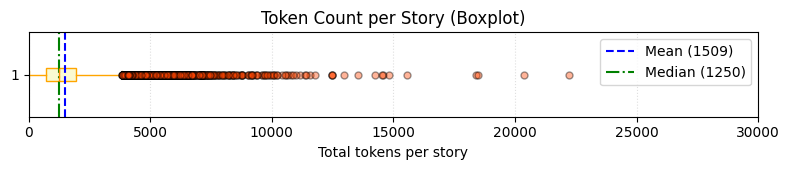

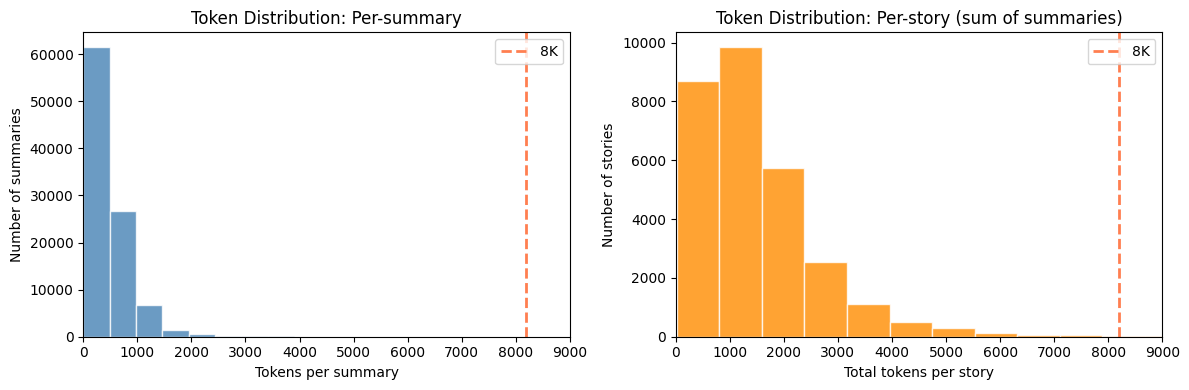


Edge Cases:
- 14 stories (0.05% of all stories) have at least one summary exceeding 8K tokens.
- 14 summaries (0.01% of all summaries) exceed 8K tokens.

Table: Summaries exceeding 8K tokens (one row per summary; sorted by n_tokens descending; ID = row index).


,wikidata_id,language,n_tokens
ID,,,
0,Q1216826,es,29241
1,Q374581,de,12439
2,Q2870,es,12130
3,Q123397,de,11387
4,Q492384,de,10816
5,Q161531,de,10804
6,Q478344,de,9815
7,Q183157,fr,9567
8,Q35160,fr,9249


In [15]:
# Per-story totals (one value per story)
story_token_stats = token_df.groupby("wikidata_id").agg(
    total_tokens=("n_tokens", "sum"),
).reset_index()
tokens_per_story = story_token_stats["total_tokens"]

# Get the key statistics
mean_val = tokens_per_story.mean()
std_val = tokens_per_story.std()
min_val = tokens_per_story.min()
max_val = tokens_per_story.max()
median_val = tokens_per_story.median()

# Print the key statistics
print("\033[1;33mTokens per story (total per story):\033[0m")
print(f"  Mean   = {mean_val:.2f}")
print(f"  Median = {median_val:.2f}")
print(f"  Std    = {std_val:.2f}")
print(f"  Min    = {min_val:.0f}")
print(f"  Max    = {max_val:.0f}")

# Visualize the key statistics via a boxplot
plt.figure(figsize=(8, 1.8))
box = plt.boxplot(tokens_per_story, vert=False, patch_artist=True, 
                  boxprops=dict(facecolor='lightgoldenrodyellow', color='orange'),
                  medianprops=dict(color='darkorange'),
                  whiskerprops=dict(color='orange'),
                  capprops=dict(color='orange'),
                  flierprops=dict(markerfacecolor='orangered', marker='o', markersize=5, alpha=0.4))
plt.title("Token Count per Story (Boxplot)")
plt.xlabel("Total tokens per story")
plt.grid(axis='x', linestyle=':', alpha=0.4)
plt.axvline(mean_val, color="blue", linestyle="--", label=f"Mean ({mean_val:.0f})")
plt.axvline(median_val, color="green", linestyle="-.", label=f"Median ({median_val:.0f})")
plt.xlim(0, 30000)
plt.legend()
plt.tight_layout()
plt.show()

# Print the token distributions per summary and per story
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
summary_tokens_xlim = max(9000, token_df["n_tokens"].quantile(0.99))
story_tokens_xlim = max(9000, story_token_stats["total_tokens"].quantile(0.99))

# Left: per-summary
axes[0].hist(token_df["n_tokens"], bins=60, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].axvline(8192, color="coral", linestyle="--", linewidth=2, label="8K")
axes[0].set_xlabel("Tokens per summary")
axes[0].set_ylabel("Number of summaries")
axes[0].set_title("Token Distribution: Per-summary")
axes[0].set_xlim(0, summary_tokens_xlim)
# Always show legend even if offscreen
axes[0].legend(loc="upper right")

# Right: per-story (total tokens)
axes[1].hist(story_token_stats["total_tokens"], bins=60, color="darkorange", edgecolor="white", alpha=0.8)
axes[1].axvline(8192, color="coral", linestyle="--", linewidth=2, label="8K")
axes[1].set_xlabel("Total tokens per story")
axes[1].set_ylabel("Number of stories")
axes[1].set_title("Token Distribution: Per-story (sum of summaries)")
axes[1].set_xlim(0, story_tokens_xlim)
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

# Edge Cases: Summaries over 8K
over_8k = token_df[token_df["n_tokens"] > 8192].copy()
n_summaries_over_8k = len(over_8k)
n_stories_over_8k = over_8k["wikidata_id"].nunique()
n_all_summaries = len(token_df)
n_all_stories = token_df["wikidata_id"].nunique()

# Print the edge cases
print("\n\033[1;33mEdge Cases:\033[0m")
print(f"- {n_stories_over_8k} stories ({100 * n_stories_over_8k / n_all_stories:.2f}% of all stories) "
      f"have at least one summary exceeding 8K tokens.")
print(f"- {n_summaries_over_8k} summaries ({100 * n_summaries_over_8k / n_all_summaries:.2f}% of all summaries) exceed 8K tokens.")

# Table: all summaries over 8K (ID = row index)
print("\n\033[1;33mTable: Summaries exceeding 8K tokens (one row per summary; sorted by n_tokens descending; ID = row index).\033[0m")
over_8k_display = over_8k[["wikidata_id", "summary_id", "n_tokens"]].sort_values("n_tokens", ascending=False).reset_index(drop=True)
over_8k_display = over_8k_display.rename(columns={"summary_id": "language"})
over_8k_display.index.name = "ID"
display(over_8k_display)

### Analysis 8: Outlier Summaries/Stories

This cell analyzes stories that contain at least one summary exceeding 8,192 tokens, checking how many of these stories still have enough usable summaries for retrieval after excluding overlong ones.
 
**Results:**
- There are 14 stories that each have a single summary exceeding 8K tokens.
- After excluding these long summaries, most stories still have at least two usable summaries for retrieval; specifically, 11 out of 14 remain usable for downstream tasks.

In [16]:
# 14 summaries over 8K: confirm they belong to 14 distinct stories
# and show whether each story still has ≥2 summaries for retrieval (using the others)

over_8k = token_df[token_df["n_tokens"] > 8192].copy()
story_ids_over_8k = over_8k["wikidata_id"].unique()
assert len(story_ids_over_8k) == 14, "Expected 14 distinct stories"

# Per story: total summaries, how many over 8K, how many under 8K (usable)
rows = []
for wid in story_ids_over_8k:
    sub = token_df[token_df["wikidata_id"] == wid]
    n_total = len(sub)
    n_over_8k = (sub["n_tokens"] > 8192).sum()
    n_under_8k = n_total - n_over_8k
    still_usable = n_under_8k >= 2
    rows.append({
        "wikidata_id": wid,
        "n_summaries_total": n_total,
        "n_over_8K": n_over_8k,
        "n_under_8K": n_under_8k,
        "still_usable_for_retrieval": still_usable,
    })

table = pd.DataFrame(rows)
print("\033[1;33m14 stories that have at least one summary > 8K tokens:\033[0m")
print("- Each has exactly one such summary (14 distinct stories, 14 over-8K summaries).")
print("- Still usable for retrieval = after excluding the long summary, ≥2 summaries remain.")
print(f"- Stories still usable for retrieval (≥2 summaries under 8K): {table['still_usable_for_retrieval'].sum()} / 14 ({100 * table['still_usable_for_retrieval'].sum() / 14:.1f}%)")
display(table)


14 stories that have at least one summary > 8K tokens:
- Each has exactly one such summary (14 distinct stories, 14 over-8K summaries).
- Still usable for retrieval = after excluding the long summary, ≥2 summaries remain.
- Stories still usable for retrieval (≥2 summaries under 8K): 11 / 14 (78.6%)


,wikidata_id,n_summaries_total,n_over_8K,n_under_8K,still_usable_for_retrieval
0,Q1211857,3,1,2,True
1,Q1216826,5,1,4,True
2,Q123397,2,1,1,False
3,Q131719,3,1,2,True
4,Q161531,5,1,4,True
5,Q183157,3,1,2,True
6,Q2870,4,1,3,True
7,Q35160,3,1,2,True
8,Q374581,2,1,1,False
9,Q386431,4,1,3,True


### Analysis 9: Split Representation Analysis

The main purpose here is to ensure that downstream experiments in the English pipeline are valid and that evaluation and training are carried out on appropriate, representative subsets.

**This section will:**
- Examine which split(s) were used in the original TellMeAgain! dataset and their characteristics.
- Analyze whether the official split is representative for our *pipeline-eligible* (EN-only) subset — i.e., those summaries that would be eligible for our English-only MAVEN pipeline.
- Assess what proportion of the split is actually pipeline-eligible and where non-eligibility arises.
- Explore alternative splitting strategies and compare their characteristics: for example, how many works and summaries are available in each split if we restrict to pipeline-eligible cases, and whether new stratified or random splits might offer advantages.

**Results:**
- train and validation (dev) splits represent the full dataset with respect to summary length, number of genres, and proportion of genres by type. 

In [17]:
# Remove stories with no genre (n_genres == 0)
pipeline_eligible_with_genre_df = pipeline_eligible_df[pipeline_eligible_df["n_genres"] > 0].copy()
print(f"Pipeline-eligible (with genre): {len(pipeline_eligible_with_genre_df)} (dropped {len(pipeline_eligible_df) - len(pipeline_eligible_with_genre_df)} with no genre)")

# Split the dataset into train, dev, and test sets using their official split method
split_ids = {}
with zipfile.ZipFile(TELL_ME_AGAIN_ZIP_RAW) as z:
    for name in ["train", "dev", "test"]:
        fname = f"{name}_stories.csv"
        if fname in z.namelist():
            with z.open(fname) as f:
                split_ids[name] = set("Q" + line.strip().decode().strip() for line in f if line.strip())


# Map each wikidata_id to its split and attach it to pipeline_eligible_with_genre_df
def get_split(wikidata_id):
    if wikidata_id in split_ids.get("train", set()):
        return "train"
    if wikidata_id in split_ids.get("dev", set()):
        return "dev"
    if wikidata_id in split_ids.get("test", set()):
        return "test"
    return "other"
pipeline_eligible_with_genre_df["split"] = pipeline_eligible_with_genre_df["wikidata_id"].map(get_split)

Pipeline-eligible (with genre): 27986 (dropped 1096 with no genre)


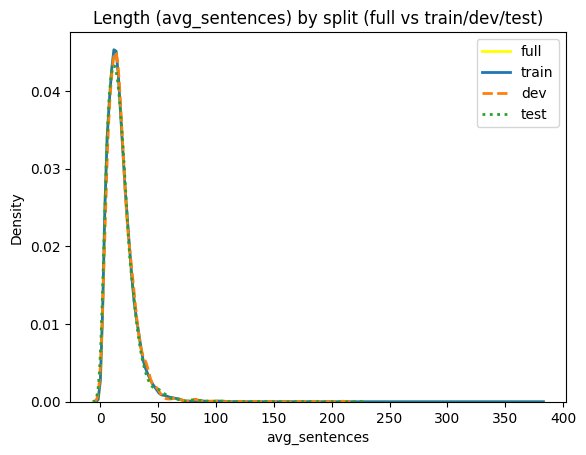

In [18]:
# Assess the representativeness of the official split based on Length
# Full eligible = pipeline_eligible_with_genre_df; add a "full" label for comparison
df = pipeline_eligible_with_genre_df.copy()
df["subset"] = df["split"].map({"train": "train", "dev": "dev", "test": "test"})

# Summary stats for a length variable (e.g. avg_sentences)
length_col = "avg_sentences"  # or "max_sentences"
stats_full = df[length_col].describe()
stats_train = df.loc[df["split"] == "train", length_col].describe()
stats_dev   = df.loc[df["split"] == "dev", length_col].describe()
pd.DataFrame({"full": stats_full, "train": stats_train, "dev": stats_dev})

# Plot: full + train, dev, test
sns.kdeplot(data=df, x="avg_sentences", label="full", linewidth=2, linestyle="-", color="yellow")
for split, ls in [("train", "-"), ("dev", "--"), ("test", ":")]:
    subset = df[df["split"] == split]
    sns.kdeplot(data=subset, x="avg_sentences", label=split, linewidth=2, linestyle=ls)
plt.legend()
plt.title("Length (avg_sentences) by split (full vs train/dev/test)")
plt.show()


Number of genre types by split (full vs train/dev/test):


,full,train,dev,test
count,27986.000000,22390.000000,2787.000000,2809.000000
mean,2.262131,2.266994,2.264442,2.221075
std,1.368408,1.367259,1.387322,1.358433
min,1.000000,1.000000,1.000000,1.000000
25%,1.000000,1.000000,1.000000,1.000000
50%,2.000000,2.000000,2.000000,2.000000
75%,3.000000,3.000000,3.000000,3.000000
max,12.000000,12.000000,10.000000,10.000000


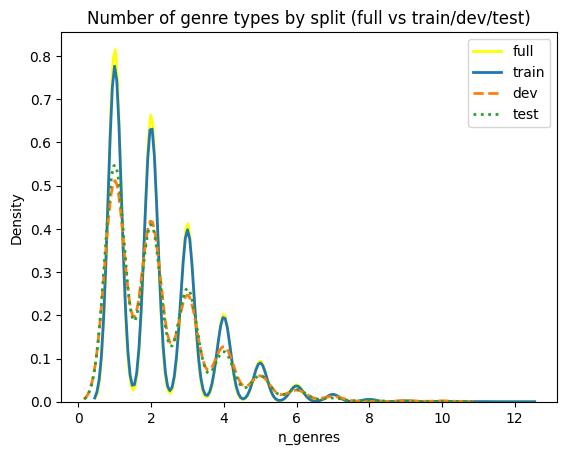

Representativeness by genre: proportion within each split (top genres):


split,dev,test,train,full
genres,,,,
Q130232,0.198542,0.196987,0.195319,0.195805
Q157443,0.070829,0.067639,0.074491,0.073450
Q188473,0.046744,0.046161,0.047342,0.047166
Q959790,0.037870,0.035262,0.036723,0.036694
Q200092,0.036920,0.034621,0.036349,0.036236
Q1054574,0.034226,0.032698,0.032093,0.032366
Q2484376,0.030265,0.032858,0.032822,0.032571
Q52207399,0.026145,0.028210,0.027030,0.027058
Q860626,0.027729,0.026607,0.025178,0.025573


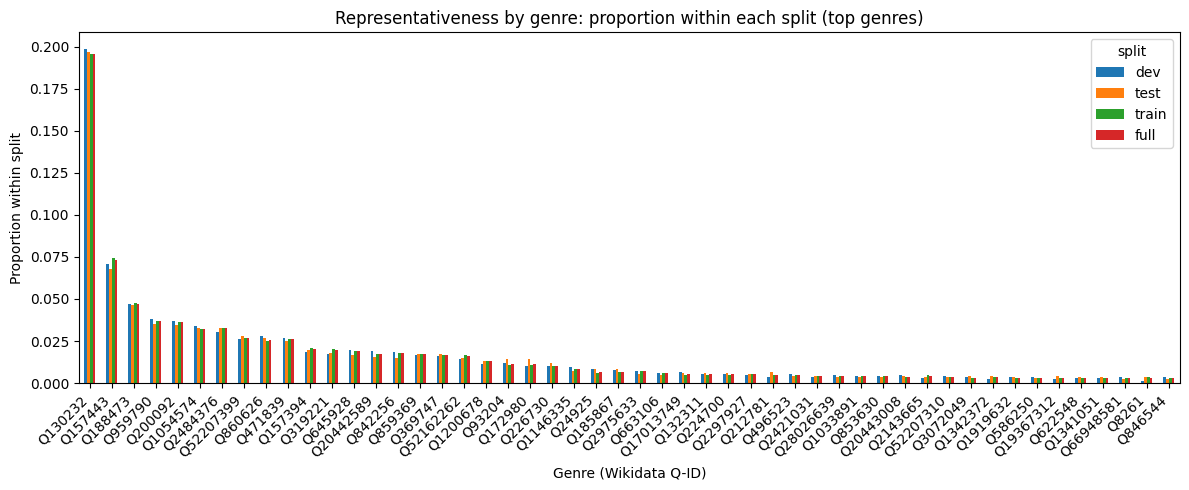

In [19]:
# Representativeness by number of genre types (n_genres)
df = pipeline_eligible_with_genre_df.copy()

# Get the statistics for splits
stats_full  = df["n_genres"].describe()
stats_train = df.loc[df["split"] == "train", "n_genres"].describe()
stats_dev   = df.loc[df["split"] == "dev", "n_genres"].describe()
stats_test  = df.loc[df["split"] == "test", "n_genres"].describe()

print("\033[1;33mNumber of genre types by split (full vs train/dev/test):\033[0m")
display(pd.DataFrame({"full": stats_full, "train": stats_train, "dev": stats_dev, "test": stats_test}))

# Plot: full + train/dev/test
sns.kdeplot(data=df, x="n_genres", label="full", linewidth=2, linestyle="-", color="yellow")
for split, ls in [("train", "-"), ("dev", "--"), ("test", ":")]:
    subset = df[df["split"] == split]
    sns.kdeplot(data=subset, x="n_genres", label=split, linewidth=2, linestyle=ls)
plt.legend()
plt.title("Number of genre types by split (full vs train/dev/test)")
plt.xlabel("n_genres")
plt.show()

# Representativeness by genre types (proportion of each genre within each split)

# copy pipeline_eligible_with_genre_df
df = pipeline_eligible_with_genre_df.copy()

def get_genres(wikidata_id):
    """Return the genres for a given Wikidata ID, handling both 'Q'-prefixed and non-prefixed keys, or an empty list if not found."""
    key = wikidata_id[1:] if isinstance(wikidata_id, str) and wikidata_id.startswith("Q") else wikidata_id
    try:
        return storyDataset[key].genres
    except KeyError:
        return []

# map each wikidata_id to its genres
df["genres"] = df["wikidata_id"].map(get_genres)

# explode the genres list and drop rows with empty genres
genre_long = df.explode("genres").dropna(subset=["genres"])[["split", "genres"]]

# Count (split × genre) → proportion within each split
counts = genre_long.groupby(["split", "genres"]).size().unstack(fill_value=0)   # count per (split, genre)
counts = counts.copy() 
counts.loc["full"] = counts.sum(axis=0)                                         # add a "full" row = total count per genre (sum over train/dev/test)
props = counts.div(counts.sum(axis=1), axis=0)                                  # each row (full, train, dev, test) sums to 1
top_n = 50                                                                      # top 50 genres
top_genres = props.sum().nlargest(top_n).index                                  # top 50 genres by total proportion
summary = props[top_genres].T.astype(float)                                     # rows = genres, cols = train/dev/test
print("\033[1;33mRepresentativeness by genre: proportion within each split (top genres):\033[0m")
display(summary)

# Plot: top 15 genres by total proportion within each split
summary.plot(kind="bar", figsize=(12, 5))
plt.ylabel("Proportion within split")
plt.xlabel("Genre (Wikidata Q-ID)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="split")
plt.title("Representativeness by genre: proportion within each split (top genres)")
plt.tight_layout()
plt.show()


### Analysis 10: Baseline from Original Distribution

This section establishes reference baselines for our similarity task *without* using any trained or pretrained models. Instead, we focus on baselines derived only from the empirical distribution of similarity scores and class labels in our dataset. 

**This section will:**
- Compute the distribution of pairwise similarity scores (or class labels, if pairs are already labeled).
- Determine the class balance: the proportion of "positive" (similar) versus "negative" (dissimilar) pairs under a chosen similarity threshold or annotation definition.
- Calculate the accuracy of a simple majority-class predictor, which always guesses the most common class in the data.
- Report the resulting expected baseline accuracy. Any system must exceed this value to demonstrate skill.

**Results:**
- Class balance: All splits are perfectly balanced: 50% positive (same-story) and 50% negative (different-story) pairs (train: 209,160 pairs; dev: 26,160; test: 26,196).
- Majority baseline accuracy: 50.00% in train, dev, and test. Any similarity model must exceed this to demonstrate skill over the prior.

Baseline from original distribution (SimilarityDataset)

TRAIN
  Total pairs:     209160
  Positive (1):    104580  (50.00%)
  Negative (-1):   104580  (50.00%)
  Majority baseline accuracy: 50.00%

DEV
  Total pairs:     26160
  Positive (1):    13080  (50.00%)
  Negative (-1):   13080  (50.00%)
  Majority baseline accuracy: 50.00%

TEST
  Total pairs:     26196
  Positive (1):    13098  (50.00%)
  Negative (-1):   13098  (50.00%)
  Majority baseline accuracy: 50.00%

Any model must exceed the majority baseline to demonstrate skill.


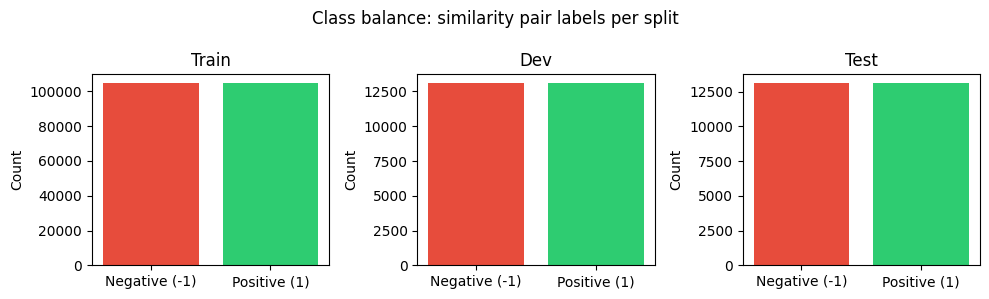

In [20]:
# Baseline from original distribution: class balance and majority-class accuracy per split
from collections import Counter

print("\033[1;33mBaseline from original distribution (SimilarityDataset)\033[0m")
for split_name in ["train", "dev", "test"]:
    ds = similarityDataset[split_name]
    labels = [item["label"] for item in ds]
    n_total = len(labels)
    counts = Counter(labels)
    n_pos = counts.get(1, 0)
    n_neg = counts.get(-1, 0)
    prop_pos = n_pos / n_total if n_total else 0
    prop_neg = n_neg / n_total if n_total else 0
    majority_accuracy = max(prop_pos, prop_neg)

    print(f"\n{split_name.upper()}")
    print(f"  Total pairs:     {n_total}")
    print(f"  Positive (1):    {n_pos}  ({prop_pos:.2%})")
    print(f"  Negative (-1):   {n_neg}  ({prop_neg:.2%})")
    print(f"  Majority baseline accuracy: {majority_accuracy:.2%}")


print("\n\033[1;33mAny model must exceed the majority baseline to demonstrate skill.\033[0m")


# Plot class balance: similarity pair labels per split
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for ax, split_name in zip(axes, ["train", "dev", "test"]):
    ds = similarityDataset[split_name]
    labels = [item["label"] for item in ds]
    counts = Counter(labels)
    ax.bar(["Negative (-1)", "Positive (1)"], [counts.get(-1, 0), counts.get(1, 0)], color=["#e74c3c", "#2ecc71"])
    ax.set_title(split_name.capitalize())
    ax.set_ylabel("Count")
plt.suptitle("Class balance: similarity pair labels per split")
plt.tight_layout()
plt.show()

## Supplementary: Exemplar Story for Thesis Paper

This section is not part of the core EDA. It identifies one of the shortest stories in the Tell Me Again! dataset so that a complete plot summary can be shown as an illustrative example in the thesis paper.

In [21]:
# Find one of the shortest stories (by English summary length in sentences)
# Only consider stories that have a native English summary and more than 2 sentences

shortest_stories = []

for story in storyDataset:
    if "en" not in story.summaries_original:
        continue
    en_summary = story.summaries_original["en"]
    n_sents = story.num_sentences.get("en", 0)
    if n_sents <= 8:
        continue
    n_words = len(en_summary.split())
    shortest_stories.append((n_sents, n_words, story.wikidata_id, story.title, en_summary))

# Sort by number of sentences, then by word count
shortest_stories.sort(key=lambda x: (x[0], x[1]))

# Show the top-10 shortest to pick a good exemplar
print("Top-10 shortest stories (by sentence count, then word count, >2 sentences):\n")
print(f"{'Rank':<5} {'Sents':<6} {'Words':<7} {'Wikidata ID':<14} {'Title'}")
print("-" * 80)
for i, (n_sents, n_words, wid, title, _) in enumerate(shortest_stories[:10]):
    print(f"{i+1:<5} {n_sents:<6} {n_words:<7} {wid:<14} {title}")

# Display the shortest story's full summary
print("\n" + "=" * 80)
n_sents, n_words, wid, title, summary = shortest_stories[0]
print(f"\nShortest story (>2 sentences): \"{title}\" ({wid})")
print(f"Sentences: {n_sents} | Words: {n_words}\n")
print("Full English summary:")
print("-" * 80)
print(summary)

Top-10 shortest stories (by sentence count, then word count, >2 sentences):

Rank  Sents  Words   Wikidata ID    Title
--------------------------------------------------------------------------------
1     9      75      Q107393090     Luzifer
2     9      88      Q55105798      The Witness
3     9      94      Q1460050       The Heath Is Green
4     9      97      Q1194308       Witch Way Love
5     9      111     Q1984949       Like Minds
6     9      112     Q59687282      The Ground beneath my Feet
7     9      114     Q3545636       Hungry Hill
8     9      115     Q97160801      The Winter Lake
9     9      116     Q73535957      Mokihana lives in Hawaii
10    9      117     Q161574        1-2-3 Corona


Shortest story (>2 sentences): "Luzifer" (Q107393090)
Sentences: 9 | Words: 75

Full English summary:
--------------------------------------------------------------------------------
Maria (Susanne Jensen) lives secluded in the mountains with her mentally handicapped adult son Jo

### Shortest Story Exemplar: *The Valiant* (Q2541760)

**Sentences:** 3 | **Words:** 25

> Alexandria December, 1941. Two Italian frogmen are captured under suspicion of placing a mine under HMS Valiant. They are brought onto the ship for questioning.

This is the shortest English-language plot summary in the Tell Me Again! dataset (with more than 2 sentences). It can serve as a compact, illustrative example of a narrative work entry in the corpus.

## Final Dataset Size (TellMeAgain Train Split)

Applying the filtering cascade established above:
1. **Pipeline-eligible** — ≥2 deduplicated English summaries *and* has translated summaries.
2. **Has genre** — at least one Wikidata genre (needed for stratification/analysis).
3. **Under 8K tokens** — drop individual summaries exceeding the 8,192-token context limit; stories left with <2 usable summaries are excluded.
4. **Official train split** — restrict to the `train` partition from the original TellMeAgain release.

We report the final number of stories and summaries available for training.

In [22]:
# Start from pipeline-eligible + has-genre subset (already has the official split column)
final_df = pipeline_eligible_with_genre_df.copy()

# Restrict to the official train split
train_df = final_df[final_df["split"] == "train"].copy()
train_story_ids = set(train_df["wikidata_id"])

# Per-summary token counts for train stories; drop summaries >8K tokens
train_tokens = token_df[token_df["wikidata_id"].isin(train_story_ids)].copy()
train_tokens_under_8k = train_tokens[train_tokens["n_tokens"] <= 8192]

# Keep only stories that still have >=2 usable (<=8K) summaries
usable_counts = train_tokens_under_8k.groupby("wikidata_id").size()
usable_story_ids = set(usable_counts[usable_counts >= 2].index)

final_train_summaries = train_tokens_under_8k[
    train_tokens_under_8k["wikidata_id"].isin(usable_story_ids)
]

# Report
print("\033[1;33mFinal TellMeAgain train dataset (after all filters):\033[0m")
print(f"  - Pipeline-eligible + has-genre (all splits):        {len(final_df):>7,} stories")
print(f"  - Train split (before 8K token filter):              {len(train_df):>7,} stories")
print(f"  - Summaries in train (before 8K token filter):       {len(train_tokens):>7,}")
print(f"  - Summaries dropped (>8K tokens):                    {len(train_tokens) - len(train_tokens_under_8k):>7,}")
print(f"  - Stories dropped (left with <2 usable summaries):   {len(train_story_ids) - len(usable_story_ids):>7,}")
print(f"\n\033[1m  Final train stories:     {len(usable_story_ids):>7,}\033[0m")
print(f"\033[1m  Final train summaries:   {len(final_train_summaries):>7,}\033[0m")
print(f"\n  Mean summaries / story:  {len(final_train_summaries) / max(len(usable_story_ids), 1):.2f}")

# Token totals (Llama-3 tokenizer) for the final train subset
n_train_tokens   = int(final_train_summaries["n_tokens"].sum())
mean_tokens      = float(final_train_summaries["n_tokens"].mean())
median_tokens    = float(final_train_summaries["n_tokens"].median())
p95_tokens       = float(final_train_summaries["n_tokens"].quantile(0.95))
n_dropped_tokens = int(train_tokens["n_tokens"].sum() - train_tokens_under_8k["n_tokens"].sum())

print(f"\n\033[1;33mToken counts (Llama-3-8B tokenizer):\033[0m")
print(f"  Total tokens (final train summaries):  {n_train_tokens:>12,}  (~{n_train_tokens/1e6:.1f} M)")
print(f"  Tokens dropped by >8K filter:          {n_dropped_tokens:>12,}")
print(f"  Mean / median / p95 per summary:       {mean_tokens:>7.0f} / {median_tokens:>5.0f} / {p95_tokens:>5.0f}")


Final TellMeAgain train dataset (after all filters):
  - Pipeline-eligible + has-genre (all splits):         27,986 stories
  - Train split (before 8K token filter):               22,390 stories
  - Summaries in train (before 8K token filter):        75,718
  - Summaries dropped (>8K tokens):                          9
  - Stories dropped (left with <2 usable summaries):         1

  Final train stories:      22,389
  Final train summaries:    75,708

  Mean summaries / story:  3.38

Token counts (Llama-3-8B tokenizer):
  Total tokens (final train summaries):    33,977,210  (~34.0 M)
  Tokens dropped by >8K filter:               111,156
  Mean / median / p95 per summary:           449 /   311 /  1184


## Preliminary GPU / Compute Budget

This cell estimates GPU resources needed for the full pipeline on the **train split only** of *Tell Me Again!*. It uses actual counts from the filtered subset (`usable_story_ids`, `final_train_summaries`) plus documented throughput assumptions. Numbers are rough — order-of-magnitude planning, not benchmarks.

**Pipeline components (from the Methodology, §3):**
- **T1 — BERT+CRF training on MAVEN** (Wang et al. 2020 backbone). Already completed once; listed for record. Commit `147c143`.
- **T2 — BERT+CRF inference on TMA train summaries.** Sentence-level event-trigger extraction.
- **T3 — Llama-3-8B-Instruct zero-shot relation inference.** 4 structural conditions: event+temporal, event+causal, event+temporal+causal (independent), event+joint-tempo-causal.
- **T4 — Dense embedding.** E5-Mistral-7B-Instruct (`intfloat/e5-mistral-7b-instruct`) and Sentence-BERT (`all-MiniLM-L6-v2`) across 6 representation conditions (raw, event-only, e+t, e+c, e+t+c, e+joint).
- **T5 — StoryEmbed comparison baseline** (Hatzel & Biemann 2024; E5-Mistral backbone, pretrained).
- **T6 — Cosine similarity** over SimilarityDataset train pairs. GPU-trivial.
- **CPU-only:** BoW / TF-IDF baselines, optional SVD post-processing, IR metrics (P@1, P@N, MAP, NDCG, R-Precision), Mann–Whitney U tests, plotting.

Target hardware: 1× NVIDIA A100 80 GB (or equivalent). The 80 GB VRAM is driven by Llama-3-8B and E5-Mistral-7B, which both need ~16–24 GB in BF16. A 40 GB A100 also works for these two at batch sizes we need.

In [23]:
# === Preliminary GPU/compute budget (train split only) ===
# Uses variables from earlier cells:
#   - df_train, df_val           (MAVEN splits)
#   - usable_story_ids, final_train_summaries (final TMA train subset)

# -----------------------------------------------------------
# 1. Input sizes (from the actual data)
# -----------------------------------------------------------
n_maven_train   = len(df_train)
n_maven_valid   = len(df_val)

n_tma_stories   = len(usable_story_ids)
n_tma_summaries = len(final_train_summaries)
n_tma_tokens    = int(final_train_summaries["n_tokens"].sum())
avg_tokens_per_summary = float(final_train_summaries["n_tokens"].mean())

# Approximate sentences/summary from tokens (EN avg ~25 tokens/sentence).
AVG_TOKENS_PER_SENTENCE = 25
avg_sents_per_summary   = avg_tokens_per_summary / AVG_TOKENS_PER_SENTENCE
n_sentences_tma_train   = int(n_tma_tokens / AVG_TOKENS_PER_SENTENCE)

# -----------------------------------------------------------
# 2. Throughput assumptions — 1x NVIDIA A100 80 GB, BF16, batched
#    (conservative; vLLM / HF accelerate / FlashAttention assumed)
# -----------------------------------------------------------
# BERT+CRF (bert-base-uncased + CRF head, ~110 M params)
BERT_TRAIN_SEC_PER_EPOCH = 1200        # ~20 min/epoch on MAVEN train
BERT_N_EPOCHS            = 5
BERT_INFER_SENT_PER_SEC  = 250         # batched GPU inference

# Llama-3-8B-Instruct (8 B params), vLLM/SGLang batched serving
LLAMA_IN_TOK_PER_PROMPT  = 2000        # summary (~1500) + events + instruction + codebook
LLAMA_OUT_TOK_PER_PROMPT = 400         # strict JSON output
LLAMA_TPS                = 3500        # total tokens/sec (A100 80 GB, BF16, bs~64)
N_STRUCT_CONDITIONS      = 4           # e+t, e+c, e+t+c-indep, e+joint-tc

# Embedders
E5_SUMMARIES_PER_SEC        = 120      # E5-Mistral-7B, bs 8, BF16
SBERT_SUMMARIES_PER_SEC     = 2000     # MiniLM-L6-v2 (tiny)
STORYEMBED_SUMMARIES_PER_SEC = 120     # E5-Mistral backbone, similar cost

N_REP_CONDITIONS = 6                   # raw, event-only, e+t, e+c, e+t+c, e+joint

# -----------------------------------------------------------
# 3. Per-task cost
# -----------------------------------------------------------
tasks = []   # (name, seconds, gpu_mem_GB, workload_description)

# T1 BERT+CRF training on MAVEN  (one-off, already done -> reported for record)
t1_sec = BERT_TRAIN_SEC_PER_EPOCH * BERT_N_EPOCHS
tasks.append(("T1 BERT+CRF train (MAVEN) *done", t1_sec, "12-16",
              f"{n_maven_train:,} docs x {BERT_N_EPOCHS} epochs"))

# T2 BERT+CRF inference on TMA train
t2_sec = n_sentences_tma_train / BERT_INFER_SENT_PER_SEC
tasks.append(("T2 BERT+CRF infer (TMA train)", t2_sec, "4-8",
              f"~{n_sentences_tma_train:,} sentences"))

# T3 Llama-3-8B relations (4 structural conditions)
n_llama_prompts  = n_tma_summaries * N_STRUCT_CONDITIONS
llama_total_toks = n_llama_prompts * (LLAMA_IN_TOK_PER_PROMPT + LLAMA_OUT_TOK_PER_PROMPT)
t3_sec = llama_total_toks / LLAMA_TPS
tasks.append(("T3 Llama-3-8B relations", t3_sec, "20-24",
              f"{n_llama_prompts:,} prompts / {llama_total_toks/1e6:,.0f} M tokens"))

# T4a E5-Mistral embeddings (6 rep conditions)
n_e5_calls = n_tma_summaries * N_REP_CONDITIONS
t4a_sec = n_e5_calls / E5_SUMMARIES_PER_SEC
tasks.append(("T4a E5-Mistral-7B embed", t4a_sec, "16-20",
              f"{n_e5_calls:,} passes (6 conditions)"))

# T4b Sentence-BERT embeddings (6 rep conditions) — cheap
t4b_sec = n_e5_calls / SBERT_SUMMARIES_PER_SEC
tasks.append(("T4b Sentence-BERT embed", t4b_sec, "2-4",
              f"{n_e5_calls:,} passes (CPU-feasible)"))

# T5 StoryEmbed comparison (raw summaries only, single pass)
t5_sec = n_tma_summaries / STORYEMBED_SUMMARIES_PER_SEC
tasks.append(("T5 StoryEmbed baseline", t5_sec, "16-20",
              f"{n_tma_summaries:,} summaries (1 pass)"))

# T6 Cosine similarity for the full ablation grid
# Grid:
#   - 6 representation conditions x 2 trained encoders (E5-Mistral, SBERT) = 12 cells
#   - StoryEmbed baseline (frozen, raw summaries only)                     =  1 cell
N_ABLATION_CELLS = N_REP_CONDITIONS * 2 + 1                       # 13

# Each cell: every unordered summary pair scored once (cosine is symmetric).
pairs_per_cell = n_tma_summaries * (n_tma_summaries - 1) // 2
total_pairs    = pairs_per_cell * N_ABLATION_CELLS

# Compute is one (N, d) @ (d, N) matmul per cell:
#   - E5 / StoryEmbed (d=4096): ~2*N^2*d FLOPs ~ 52 TFLOPs/cell  -> <1 s on A100 BF16
#   - SBERT (d=384):           ~5 TFLOPs/cell                    -> ~0.02 s
# Wall-clock dominated by chunked top-k retrieval + I/O, ~1 min per cell.
t6_sec = 60 * N_ABLATION_CELLS

tasks.append(("T6 Cosine sim (full ablation)", t6_sec, "<8",
              f"{N_ABLATION_CELLS} cells x {pairs_per_cell:,} pairs = {total_pairs/1e9:.1f} B"))

# -----------------------------------------------------------
# 4. Print summary table
# -----------------------------------------------------------
print("\033[1;33mPipeline size inputs (TMA train split only):\033[0m")
print(f"  MAVEN train docs (BERT+CRF training):    {n_maven_train:>10,}")
print(f"  TMA final train stories:                 {n_tma_stories:>10,}")
print(f"  TMA final train summaries:               {n_tma_summaries:>10,}")
print(f"  Total tokens (Llama-3 tokenizer):        {n_tma_tokens:>10,}")
print(f"  Avg tokens / summary:                    {avg_tokens_per_summary:>10.0f}")
print(f"  Approx sentences / summary (tok/{AVG_TOKENS_PER_SENTENCE}):        {avg_sents_per_summary:>10.1f}")
print(f"  Ablation grid (cosine cells):            {N_ABLATION_CELLS:>10,}  (6 reps x 2 enc + StoryEmbed)")
print(f"  Total pairwise comparisons (T6):         {total_pairs/1e9:>10.1f} B")

print("\n\033[1;33mPer-task compute estimate (1x A100 80 GB, BF16, batched):\033[0m")
header = f"{'Task':<34} {'Hours':>8} {'Days':>6}  {'GPU GB':>7}  Workload"
print(header)
print("-" * len(header) * 1)
total_sec = 0.0
runnable_sec = 0.0   # excludes T1 (already done)
for name, sec, mem, load in tasks:
    hours = sec / 3600
    days  = hours / 24
    total_sec += sec
    if "*done" not in name:
        runnable_sec += sec
    print(f"{name:<34} {hours:>8.1f} {days:>6.2f}  {mem:>7}  {load}")
print("-" * 90)
print(f"{'TOTAL (all tasks)':<34} {total_sec/3600:>8.1f} {total_sec/86400:>6.2f}")
print(f"{'REMAINING (excl. done T1)':<34} {runnable_sec/3600:>8.1f} {runnable_sec/86400:>6.2f}")

# -----------------------------------------------------------
# 5. GPU-request summary (copy into cluster form / supervisor email)
# -----------------------------------------------------------
buffer_factor = 2.5   # debugging, prompt iteration, retries, BF16 speed variance
planned_gpu_days = runnable_sec * buffer_factor / 86400

print("\n" + "=" * 82)
print("SUMMARY FOR GPU CLUSTER / SUPERVISOR REQUEST")
print("=" * 82)
print(f"""
Models used:
  - BERT-base-uncased + CRF head (~110 M params) — trained on MAVEN (DONE).
  - Llama-3-8B-Instruct (8 B params) — zero-shot relation inference, NO training.
  - E5-Mistral-7B-Instruct (~7 B params) — frozen, instruction-tuned encoder.
  - Sentence-BERT all-MiniLM-L6-v2 (~23 M params) — frozen, CPU-feasible.
  - StoryEmbed (Hatzel & Biemann 2024, E5-Mistral backbone) — frozen baseline.

Training goal:
  Only the BERT+CRF event extractor is *trained* (on MAVEN), and that is already
  complete. Every other model runs in inference mode (zero-shot LLM or frozen
  pretrained encoder). No hyperparameter sweeps on the LLM or encoders are planned.

Dataset size (train split, after filtering):
  - MAVEN train : {n_maven_train:,} docs (used once for T1).
  - TMA train   : {n_tma_stories:,} stories / {n_tma_summaries:,} summaries / {n_tma_tokens/1e6:.1f} M tokens.
  - Ablation grid : 6 representations x 2 encoders + StoryEmbed = 13 cells.
                    Pairwise cosine = {total_pairs/1e9:.1f} B comparisons (matmul; ~1 min per cell).

GPU requirement:
  - 1x NVIDIA A100 80 GB (or H100). A 40 GB A100 is acceptable with smaller LLM
    batch sizes. A single-GPU node is sufficient (no distributed training).
  - Peak VRAM driver: Llama-3-8B and E5-Mistral-7B (both ~20 GB in BF16).

Estimated wall-clock on one A100 80 GB (train split only):
  - Raw: ~{runnable_sec/3600:.0f} GPU-hours ({runnable_sec/86400:.1f} days) for T2..T6.
  - With {buffer_factor}x buffer (debugging, prompt iteration, failed runs):
    plan for ~{planned_gpu_days:.1f} GPU-days (~{planned_gpu_days*24:.0f} hours).
  - Dev + test splits add ~{(26160+26196)/209160*100:.0f}% on top of train if run identically.

Bottleneck: T3 (Llama-3-8B across 4 structural conditions) dominates the budget
(~{t3_sec/max(runnable_sec,1)*100:.0f}% of remaining GPU time). Consider batching prompts and reusing
the same generation for conditions that share structure where possible.

CPU-only workloads:
  - BoW / TF-IDF baselines, optional SVD post-processing, retrieval metric
    computation (P@1, P@N, MAP, NDCG, R-Precision), Mann-Whitney U tests,
    plotting. ~16-32 GB RAM + 8 cores sufficient; no GPU needed.
""")

Pipeline size inputs (TMA train split only):
  MAVEN train docs (BERT+CRF training):         2,913
  TMA final train stories:                     22,389
  TMA final train summaries:                   75,708
  Total tokens (Llama-3 tokenizer):        33,977,210
  Avg tokens / summary:                           449
  Approx sentences / summary (tok/25):              18.0
  Ablation grid (cosine cells):                    13  (6 reps x 2 enc + StoryEmbed)
  Total pairwise comparisons (T6):               37.3 B

Per-task compute estimate (1x A100 80 GB, BF16, batched):
Task                                  Hours   Days   GPU GB  Workload
---------------------------------------------------------------------
T1 BERT+CRF train (MAVEN) *done         1.7   0.07    12-16  2,913 docs x 5 epochs
T2 BERT+CRF infer (TMA train)           1.5   0.06      4-8  ~1,359,088 sentences
T3 Llama-3-8B relations                57.7   2.40    20-24  302,832 prompts / 727 M tokens
T4a E5-Mistral-7B embed        